In [ ]:
############ LOAD in custom packages ################
import sys
import os
import pandas as pd
import numpy as np
import importlib
from fastdtw import dtw
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt


############ LOAD in custom packages ################

project_root = os.path.join(os.getcwd(), "..") # Get path of the project 
sys.path.append(project_root) # Add project root to sys.path for script usage

# Import and reload (optional) custom scripts
from scripts import paths
from scripts import preprocessing as pre
from scripts import visualization as vis
from scripts import variables
from scripts import feature_selection as fs
from scripts import clustering as cl

importlib.reload(paths)
importlib.reload(pre)
importlib.reload(vis)
importlib.reload(variables)
importlib.reload(fs)
importlib.reload(cl)

# Filepaths
brighten_dir = paths.DATA



################ DEFINE column variables from data ###################
from scripts.variables import id_columns, df_names, demographic_columns, daily_cols_v1, daily_cols_v2, daily_v2_common, daily_v2_weather
from scripts.variables import phq2_cols, phq9_cols, weekly_cols, passive_cols, baseline_cols, created_cols
demo_df = pd.read_csv(os.path.join(brighten_dir, f'demographics_clean.csv'))
demographic_vars = [col for col in demo_df.columns if col!='num_id' and 'Unnamed' not in col]
print(demographic_vars)
id_columns.append('idx')
time_cols = []

############## Define and load dfs ###########
dfs = {}
for name in df_names:
    for split in ['trainval']:
        dfs[name] = pd.read_csv(os.path.join(brighten_dir, f'{name}_{split}_imputed.csv'))


['phq9_1_base', 'phq9_2_base', 'phq9_3_base', 'phq9_4_base', 'phq9_5_base', 'phq9_6_base', 'phq9_7_base', 'phq9_8_base', 'phq9_9_base', 'screen_1', 'screen_2', 'screen_3', 'screen_4', 'phq9_category', 'bin_clin', 'participant_id', 'gender', 'education', 'working', 'income_satisfaction', 'income_lastyear', 'marital_status', 'race', 'age_category']


In [4]:
daily_cols_v2

['distance_walking',
 'distance_active',
 'hours_active',
 'distance_powered_vehicle',
 'hours_powered_vehicle',
 'hours_high_speed_transportation',
 'distance_high_speed_transportation',
 'location_variance',
 'came_to_work',
 'hours_of_sleep',
 'callDuration_incoming',
 'callCount_missed',
 'callCount_outgoing',
 'callCount_incoming',
 'callDuration_outgoing',
 'textCount',
 'textCount_received',
 'textCount_sent',
 'textLength_received',
 'textLength_sent',
 'uniqueNumbers_calls_incoming',
 'uniqueNumbers_calls_missed',
 'uniqueNumbers_calls_outgoing',
 'uniqueNumbers_texts',
 'uniqueNumbers_texts_received',
 'uniqueNumbers_texts_sent',
 'cloud_cover_mean',
 'dew_point_mean',
 'humidity_mean',
 'temp_mean',
 'dew_point_IQR',
 'humidity_IQR',
 'temp_IQR',
 'cloud_cover_IQR',
 'cloud_cover_std',
 'dew_point_std',
 'humidity_std',
 'temp_std',
 'cloud_cover_median',
 'dew_point_median',
 'humidity_median',
 'temp_median',
 'precip_sum']

Run on: Sun 12 Apr 2026, 10:50PM


DATAFRAME: v1_day


,aggregate_communication,call_count,call_duration,interaction_diversity,missed_interactions,sms_count,sms_length,mobility,mobility_radius,unreturned_calls
0,-0.558251,-0.201996,-0.197924,-0.364976,-0.067027,-0.550659,-0.525810,1.647668,0.553332,0.007608
1,-0.634964,-0.448868,-0.458375,-1.033784,-0.110840,-0.600128,-0.587252,2.190466,0.505272,0.119001
2,-0.634964,-0.448868,-0.461154,-0.815694,-0.548976,-0.600128,-0.587252,1.909405,0.456186,-0.527078
3,-0.422995,-0.318935,-0.058875,0.056664,-0.110840,-0.397043,-0.460152,2.106258,1.499034,-0.527078
4,-0.347293,0.460663,0.271147,-0.379515,1.203566,-0.412665,-0.523383,1.774997,1.503826,2.057239


['aggregate_communication', 'call_count', 'call_duration', 'interaction_diversity', 'missed_interactions', 'sms_count', 'sms_length', 'mobility', 'mobility_radius', 'unreturned_calls']
In df there are 189 subjects.


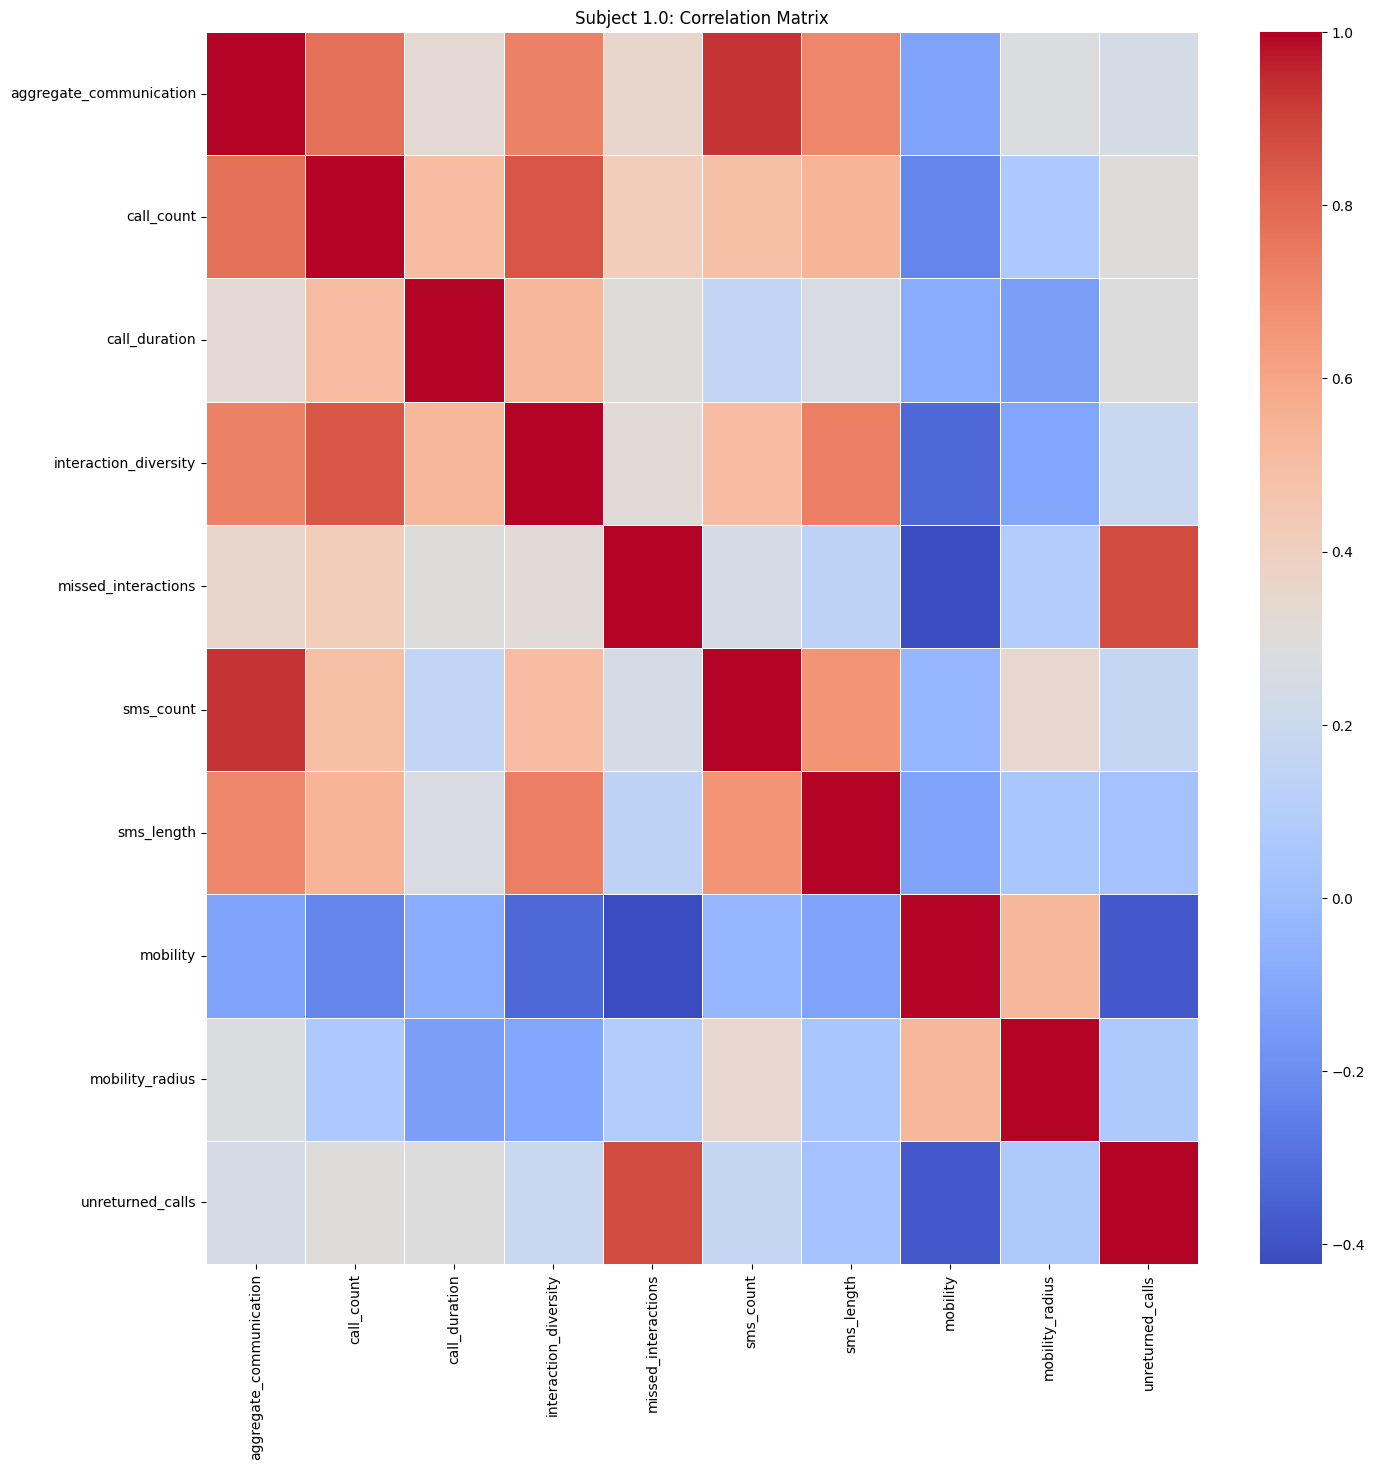

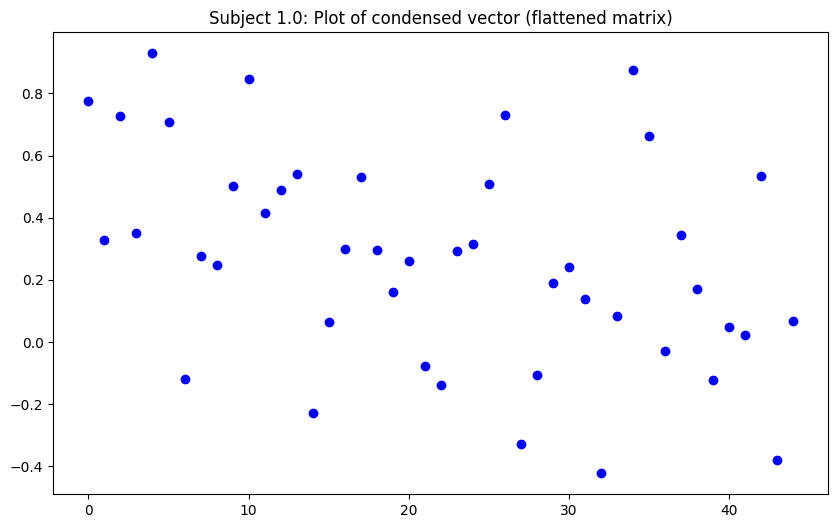

189 subs with symptom matrices
189 filled condensed arrays


DATAFRAME: v1_week


,aggregate_communication,call_count,call_duration,interaction_diversity,missed_interactions,sms_count,sms_length,mobility,mobility_radius,unreturned_calls
0,-0.601736,-0.234929,0.175619,-0.515214,0.088850,-0.592567,-0.644041,2.174611,0.883111,0.231650
1,-0.613992,-0.230638,-0.371887,-0.267755,0.151585,-0.605652,-0.567361,1.889811,0.488958,0.074427
2,-0.646674,0.026811,-0.263720,-0.189610,-0.130723,-0.667335,-0.645035,2.032211,0.686035,0.096887
3,-0.616715,-0.333618,-0.538210,-0.541262,-0.507134,-0.597240,-0.631487,2.032211,0.686035,-0.307402
4,-0.706591,-0.505250,0.034815,-0.697552,0.308423,-0.671074,-0.660690,2.032211,0.686035,0.546097


['aggregate_communication', 'call_count', 'call_duration', 'interaction_diversity', 'missed_interactions', 'sms_count', 'sms_length', 'mobility', 'mobility_radius', 'unreturned_calls']
In df there are 180 subjects.


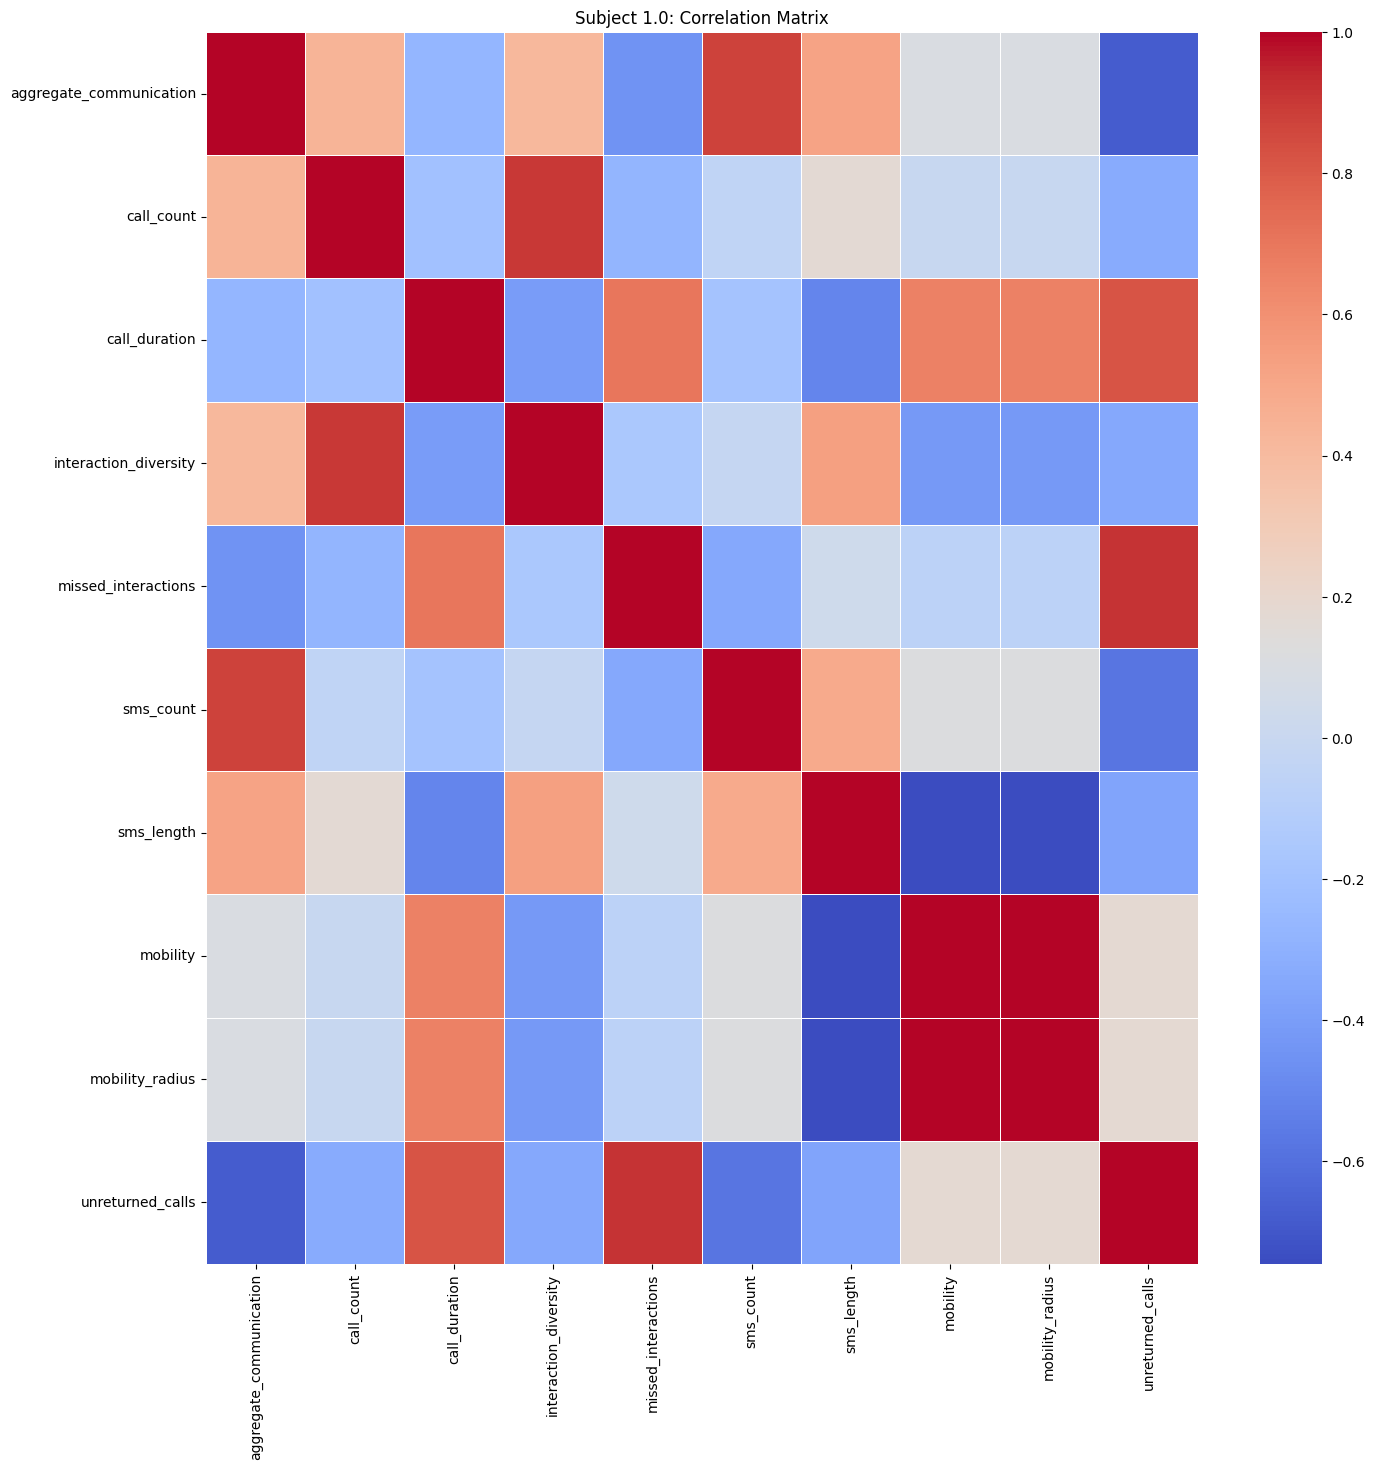

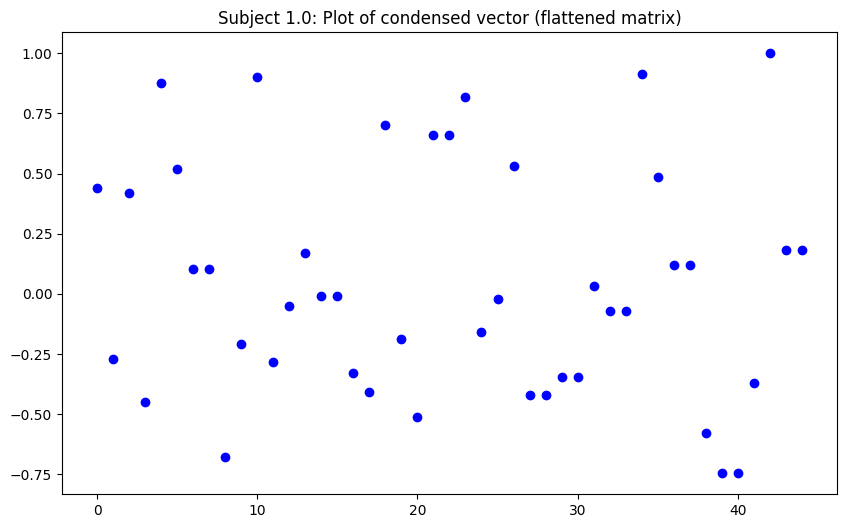

180 subs with symptom matrices
180 filled condensed arrays


DATAFRAME: v2_day


,distance_walking,distance_active,hours_active,distance_powered_vehicle,hours_powered_vehicle,hours_high_speed_transportation,distance_high_speed_transportation,location_variance,came_to_work,hours_of_sleep,...,cloud_cover_IQR,cloud_cover_std,dew_point_std,humidity_std,temp_std,cloud_cover_median,dew_point_median,humidity_median,temp_median,precip_sum
0,0.144162,-0.591287,-1.075658,1.167348,1.527253,4.198794,5.083306,1.164222,-0.365128,-0.248545,...,-0.488591,-0.396176,-0.745091,0.796627,0.673011,-1.158677,1.963274,-0.268274,2.109752,-0.580411
1,-1.320046,-1.692179,-1.357496,-1.426044,-1.159834,-0.193354,-0.196722,-0.333342,-0.365128,1.545778,...,0.680830,0.480214,-0.571171,1.371096,0.955373,-0.665753,1.834662,0.188432,1.884220,0.803026
2,-1.320046,-1.692179,-1.357496,-1.426044,-1.159834,-0.193354,-0.196722,-2.134033,-0.365128,1.407286,...,1.667529,1.210540,-0.566340,1.371096,1.220305,-0.616460,1.698322,0.530962,1.485632,2.277666
3,0.848851,0.223564,0.624649,-0.347207,-1.088558,-0.193354,-0.196722,0.060854,2.738767,-0.099510,...,0.827008,0.407182,-0.281305,0.988117,0.868224,0.024342,1.858397,0.245520,1.820022,-0.138832
4,0.859223,0.360217,0.727827,-1.426044,-1.159834,-0.193354,-0.196722,0.079493,2.738767,-0.070279,...,0.205753,0.334149,-0.909348,1.562586,0.840336,0.048988,1.719297,0.359697,1.700557,2.276971


['distance_walking', 'distance_active', 'hours_active', 'distance_powered_vehicle', 'hours_powered_vehicle', 'hours_high_speed_transportation', 'distance_high_speed_transportation', 'location_variance', 'came_to_work', 'hours_of_sleep', 'cloud_cover_mean', 'dew_point_mean', 'humidity_mean', 'temp_mean', 'dew_point_IQR', 'humidity_IQR', 'temp_IQR', 'cloud_cover_IQR', 'cloud_cover_std', 'dew_point_std', 'humidity_std', 'temp_std', 'cloud_cover_median', 'dew_point_median', 'humidity_median', 'temp_median', 'precip_sum']
In df there are 161 subjects.


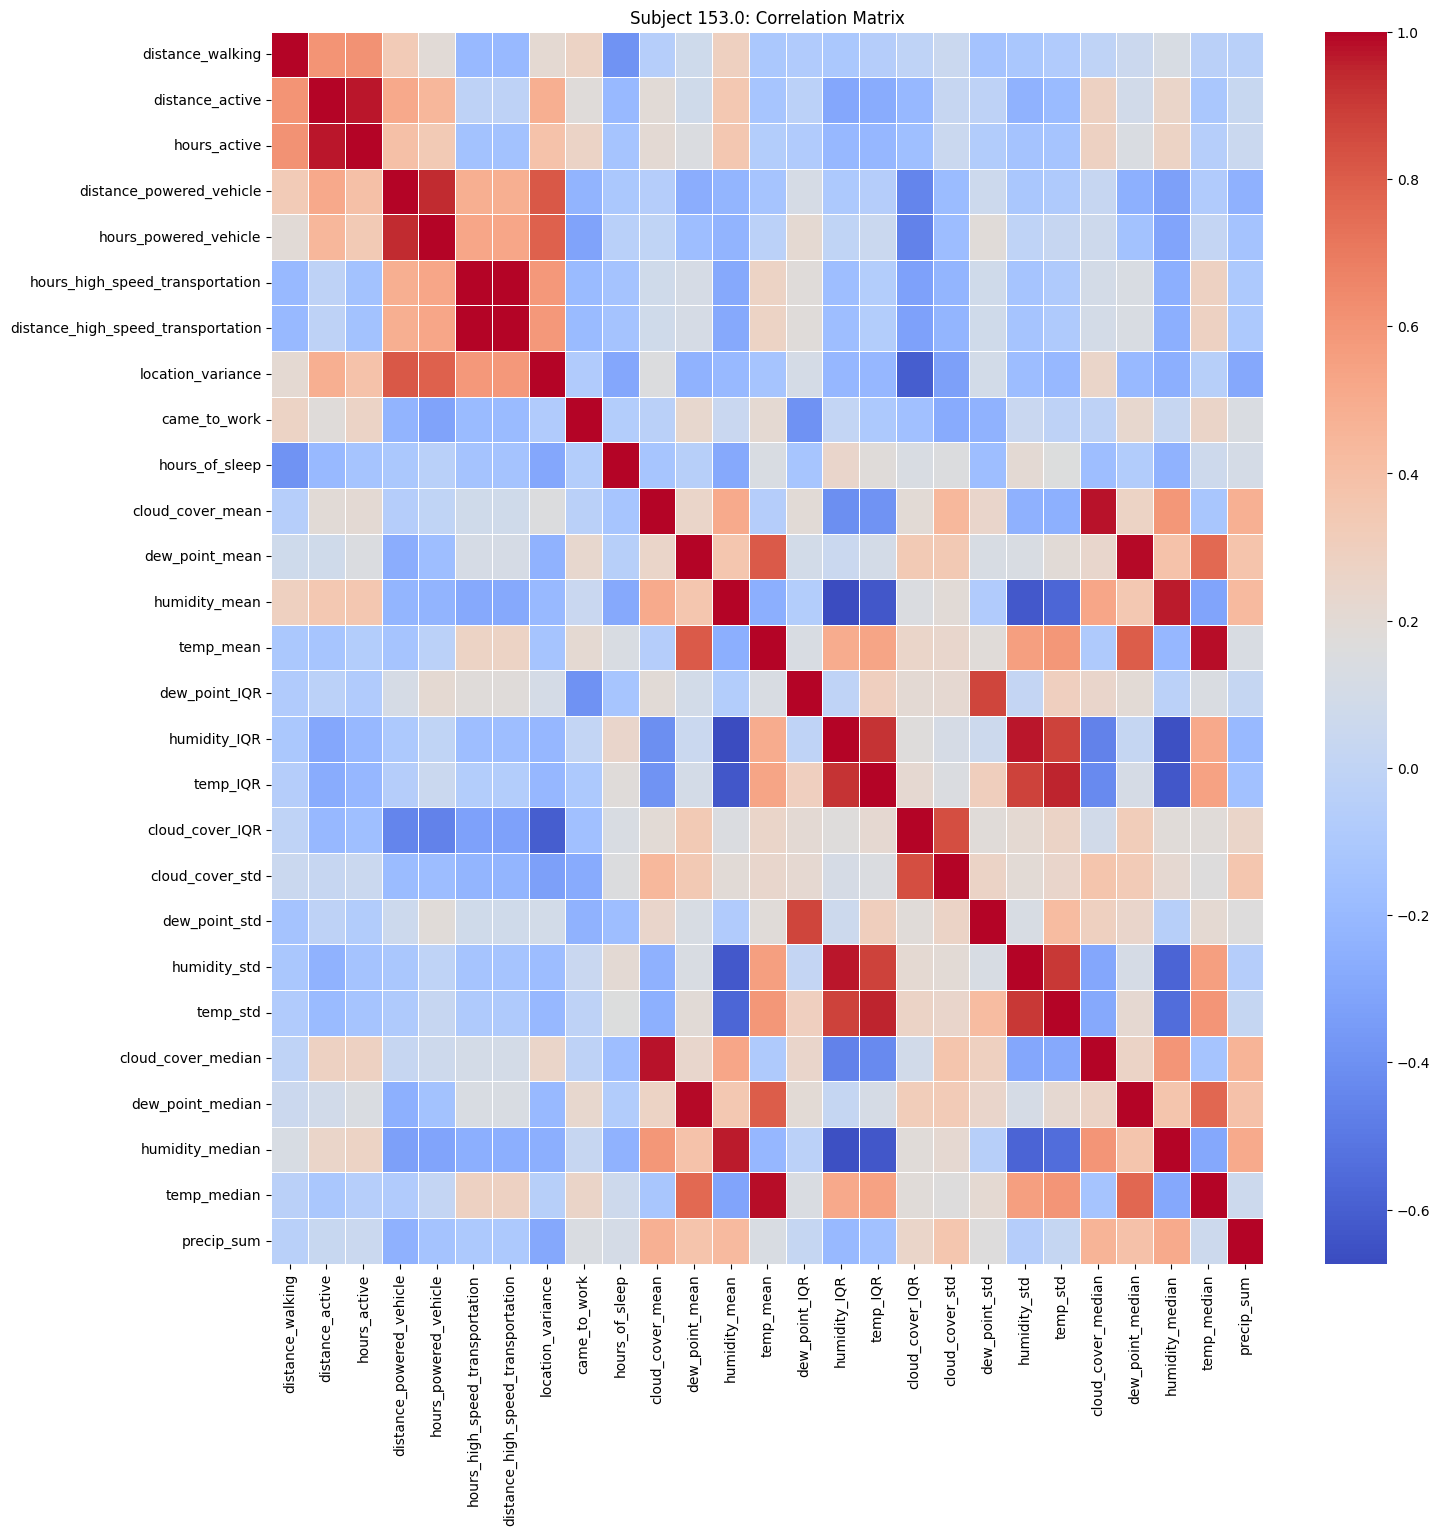

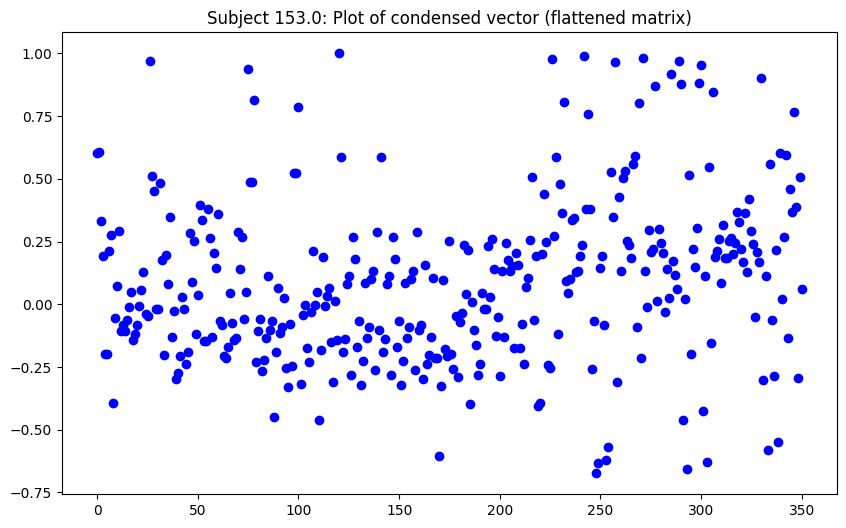

161 subs with symptom matrices
161 filled condensed arrays


DATAFRAME: v2_week


,distance_walking,distance_active,hours_active,distance_powered_vehicle,hours_powered_vehicle,hours_high_speed_transportation,distance_high_speed_transportation,location_variance,came_to_work,hours_of_sleep,...,cloud_cover_IQR,cloud_cover_std,dew_point_std,humidity_std,temp_std,cloud_cover_median,dew_point_median,humidity_median,temp_median,precip_sum
0,0.279157,-0.689472,-0.470925,-0.193791,-0.485520,0.042492,2.069189,-0.213285,1.831350,0.476940,...,0.765604,0.386421,-1.161011,1.989878,1.189564,-0.675329,1.920279,0.291152,1.832658,1.519397
1,1.095057,0.715554,0.993516,0.479544,0.433552,-0.326715,-0.478665,0.700174,1.598642,0.248298,...,0.006369,0.125706,-0.633384,0.783598,0.648902,-0.857696,1.641508,0.111564,1.531146,0.395146
2,-0.200794,-0.757585,-0.771687,-1.438350,-1.541384,-0.326715,-0.478665,-0.103298,1.806629,0.055991,...,0.069638,-0.455888,-1.093579,0.352784,0.145908,-0.904590,1.606767,0.450785,1.426496,0.214517
3,1.010552,1.024725,0.982746,1.499205,1.356401,0.042492,2.071635,0.896299,-0.591577,0.527741,...,-0.167623,0.326256,-0.789543,0.654354,0.260393,0.246927,1.484626,0.365980,1.321560,-0.659173
4,-2.227640,-2.438495,-1.974613,-2.156653,-1.667372,-0.326715,-0.478665,0.319973,-0.591577,-0.114734,...,0.565251,0.085596,-1.149181,0.654354,-0.805421,1.143131,1.723609,0.889777,1.376830,-0.970441


['distance_walking', 'distance_active', 'hours_active', 'distance_powered_vehicle', 'hours_powered_vehicle', 'hours_high_speed_transportation', 'distance_high_speed_transportation', 'location_variance', 'came_to_work', 'hours_of_sleep', 'cloud_cover_mean', 'dew_point_mean', 'humidity_mean', 'temp_mean', 'dew_point_IQR', 'humidity_IQR', 'temp_IQR', 'cloud_cover_IQR', 'cloud_cover_std', 'dew_point_std', 'humidity_std', 'temp_std', 'cloud_cover_median', 'dew_point_median', 'humidity_median', 'temp_median', 'precip_sum']
In df there are 147 subjects.


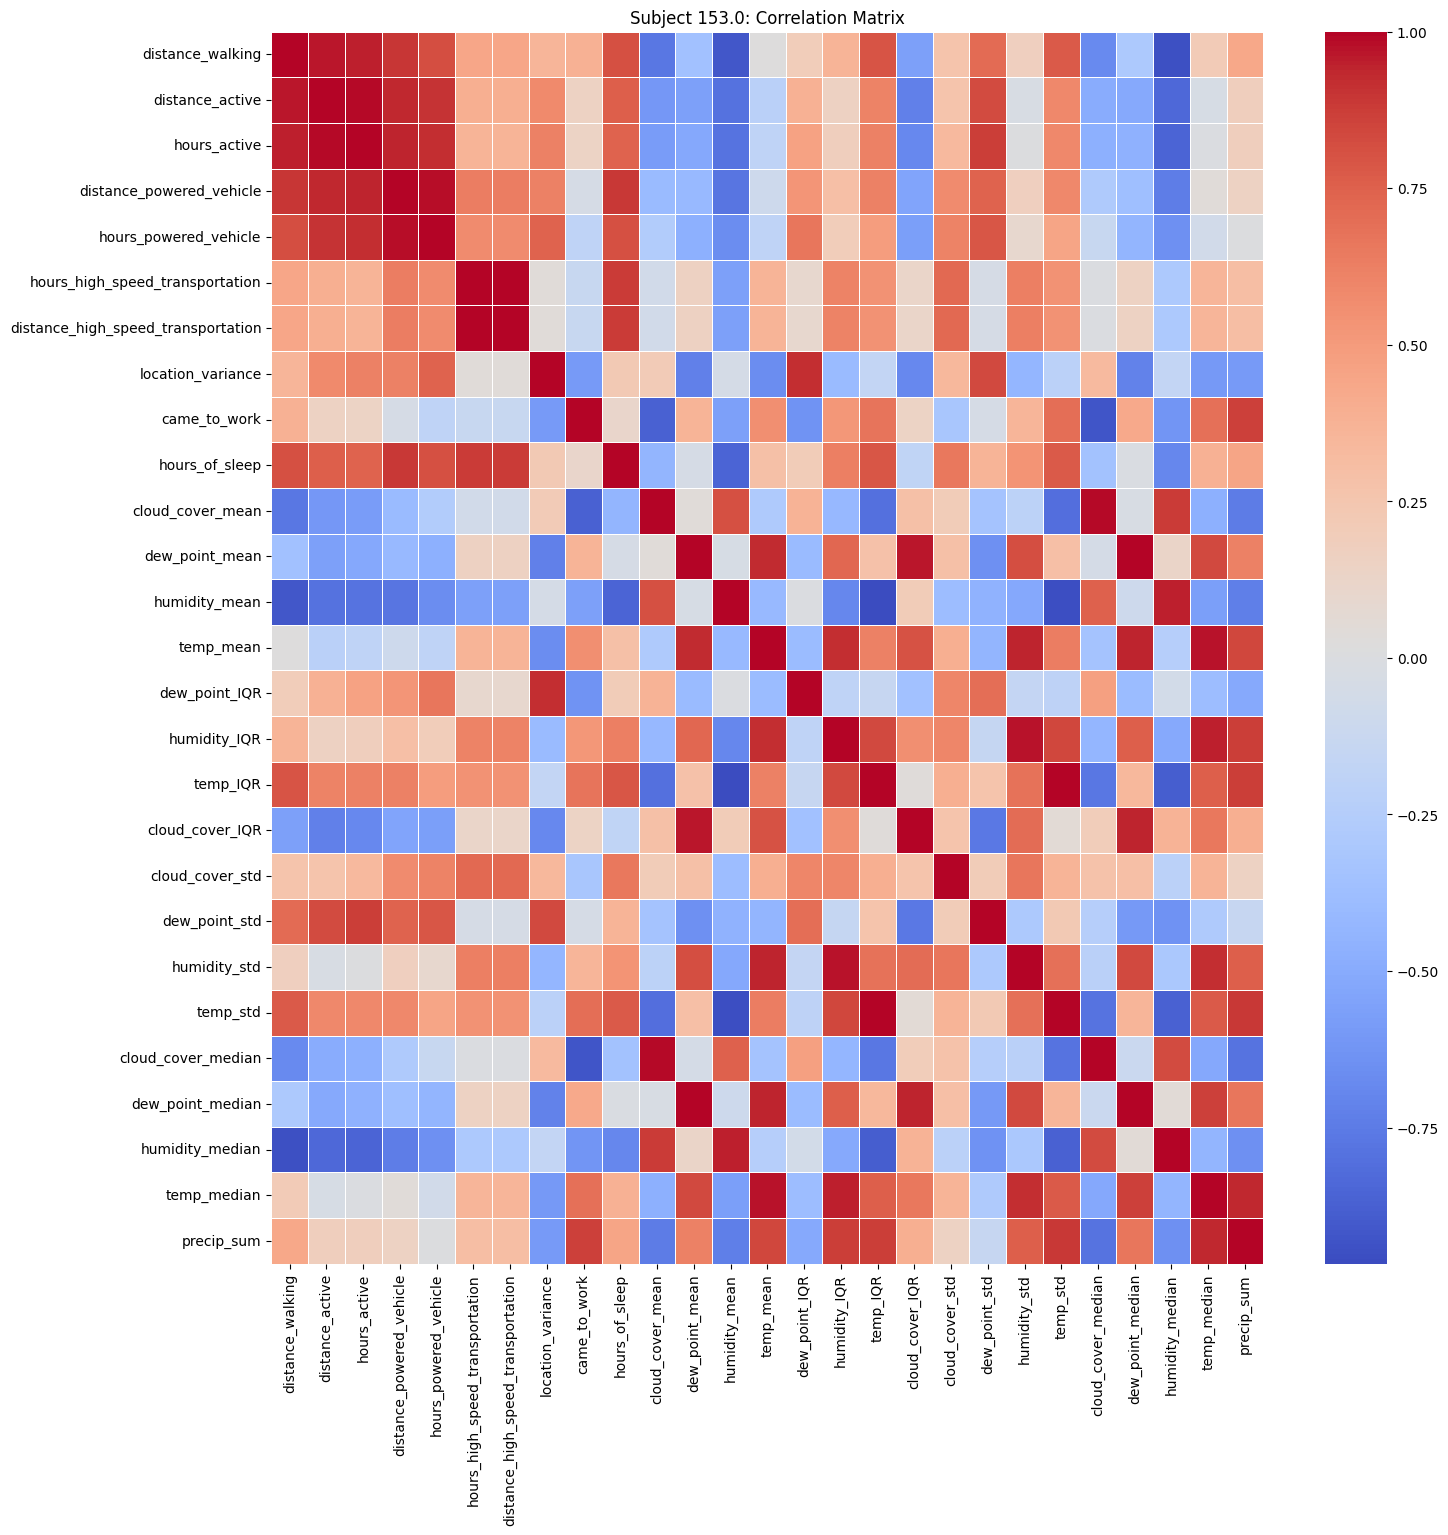

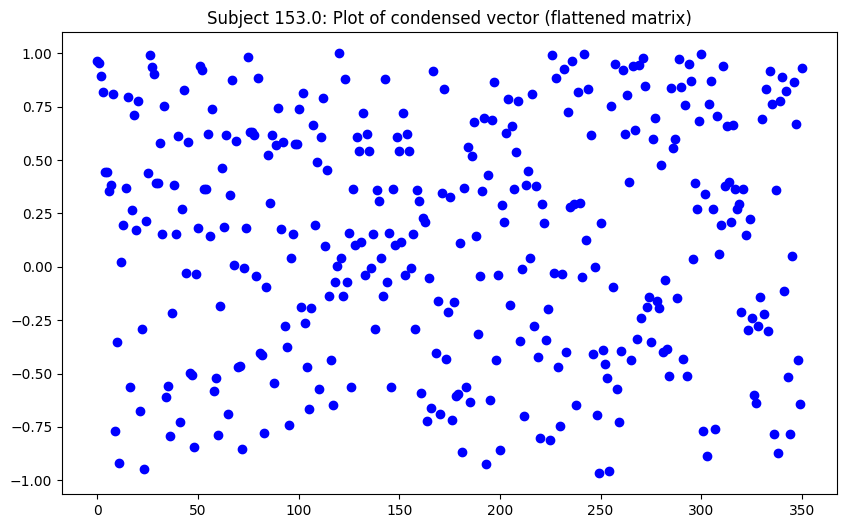

147 subs with symptom matrices
147 filled condensed arrays


In [ ]:
#### Take the average of each subject's symptom correlation and use it to make clusters of variables
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

symptom_matrices_df_dict = {}
flattened_matrices_df_dict = {}
target_cols = phq2_cols+phq9_cols
non_pca_cols = {}

# Create dicts of all subjects' correlation matrices
for name in ['v1_day','v1_week','v2_day','v2_week']:
	df = dfs[name].copy()
	
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
	df = df.loc[:, ~df.columns.str.contains('_indicator')]
	df = df.loc[:, ~df.columns.str.contains('_nan')]
	# take out time cols, nonnumeric cols, baseline cols
	numeric_cols = df.select_dtypes(include=('int64','float64')).columns.to_list()
	nonnumeric_cols = [col for col in df.columns if col not in numeric_cols]
	time_cols = [col for col in df.columns if 'season' in col or 'dt' in col]
	fully_empty_cols = [col for col in df.columns if 'hours' in col]
	rando_cols = [col for col in df.columns if 'user_phone_type' in col or 'race' in col or 'cohort' in col or 'marital_status' in col or 'gender' in col or 'Akili' in col]
	non_pca_cols[name] = weekly_cols+demographic_vars+time_cols+id_columns+nonnumeric_cols+baseline_cols+rando_cols+created_cols+fully_empty_cols
	
	column_order_all = daily_cols_v1 + daily_cols_v2
	column_order = [col for col in column_order_all if col in df.columns]
	print(f'\n\nDATAFRAME: {name}')
	display(df[column_order].head())
	print(column_order)
	symptom_matrix_dict, flattened_matrix_dict = fs.make_symptom_matrices(df, ignore_cols=non_pca_cols[name], num_to_plot=1, column_order=column_order)
	symptom_matrices_df_dict[name] = symptom_matrix_dict
	flattened_matrices_df_dict[name] = flattened_matrix_dict



In [6]:
column_order

['distance_walking',
 'distance_active',
 'hours_active',
 'distance_powered_vehicle',
 'hours_powered_vehicle',
 'hours_high_speed_transportation',
 'distance_high_speed_transportation',
 'location_variance',
 'came_to_work',
 'hours_of_sleep',
 'cloud_cover_mean',
 'dew_point_mean',
 'humidity_mean',
 'temp_mean',
 'dew_point_IQR',
 'humidity_IQR',
 'temp_IQR',
 'cloud_cover_IQR',
 'cloud_cover_std',
 'dew_point_std',
 'humidity_std',
 'temp_std',
 'cloud_cover_median',
 'dew_point_median',
 'humidity_median',
 'temp_median',
 'precip_sum']

Run on: Sun 12 Apr 2026, 10:50PM


DATAFRAME: v1_day
In df there are 189 subjects.
189 subs with symptom matrices
189 filled condensed arrays
In df there are 189 subjects.


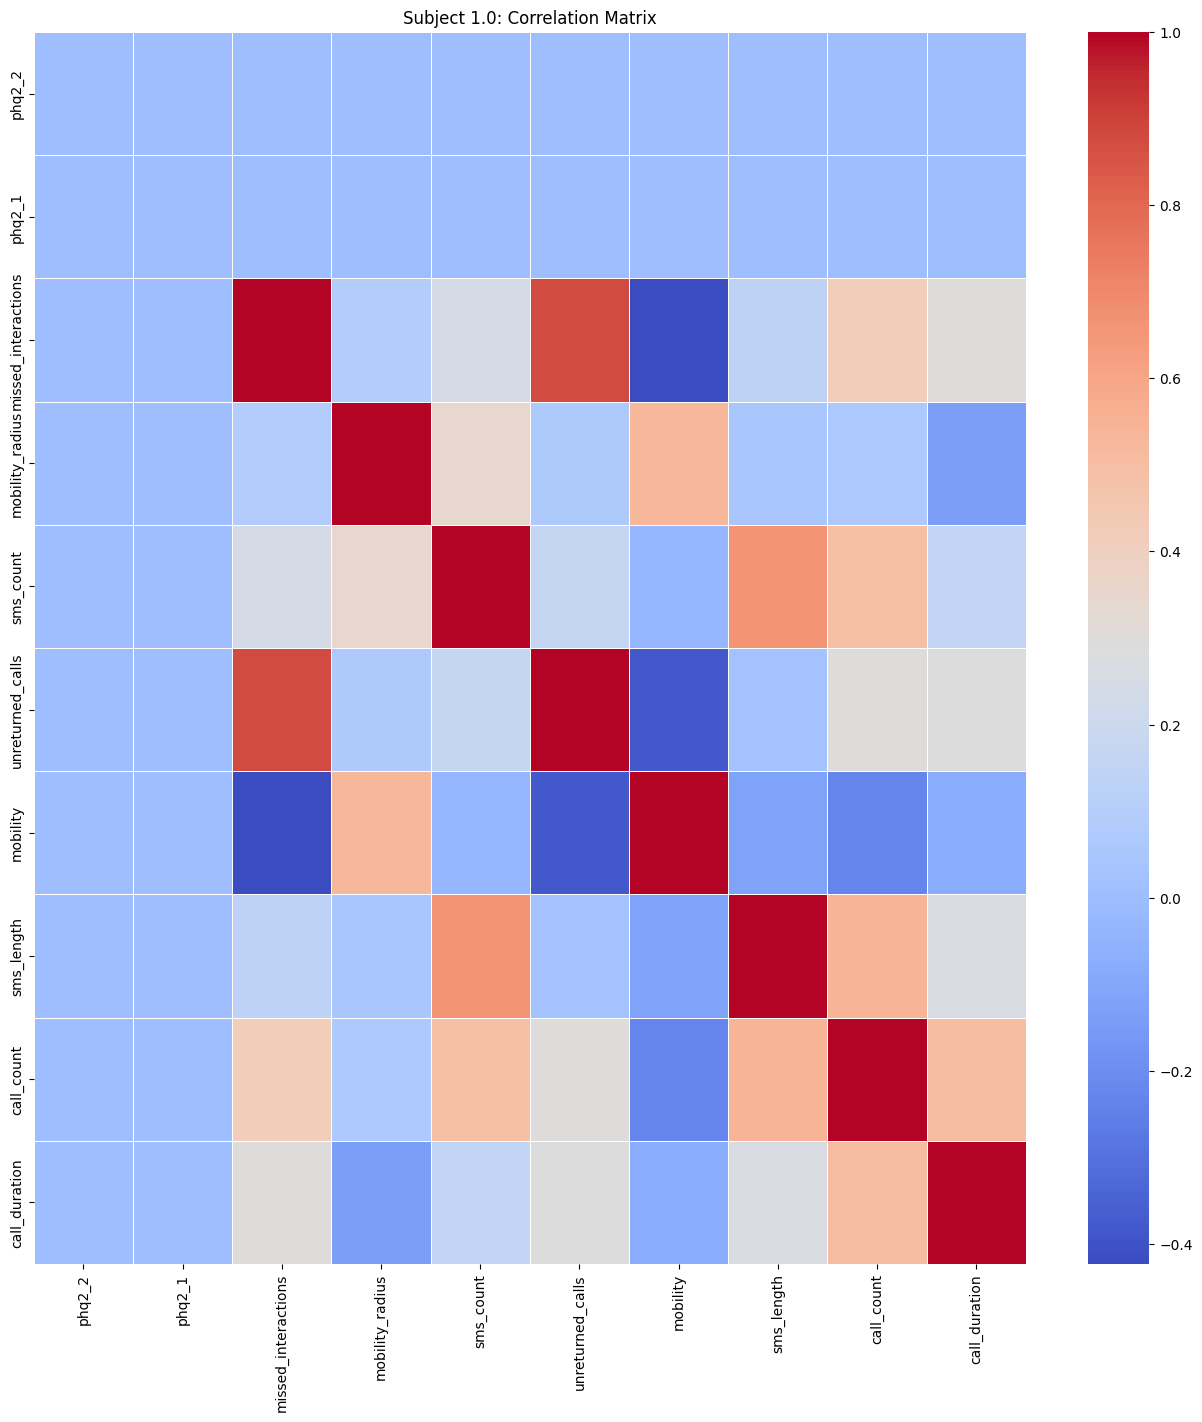

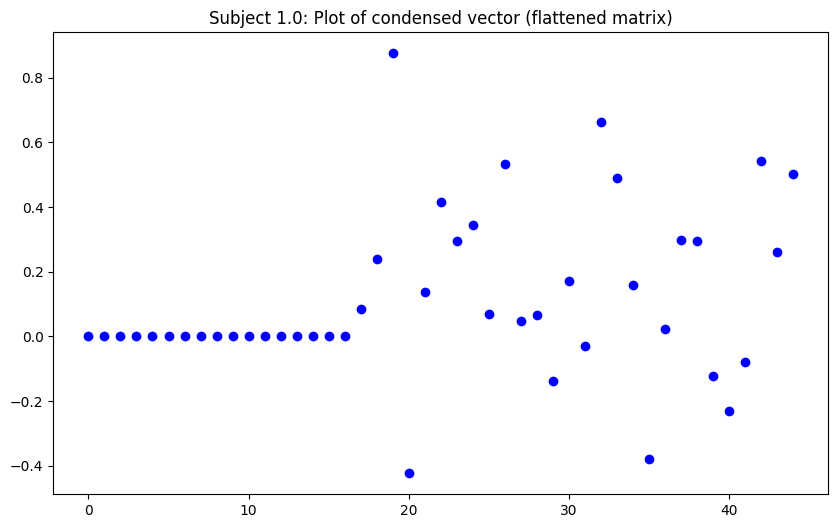

189 subs with symptom matrices
189 filled condensed arrays
In df there are 189 subjects.


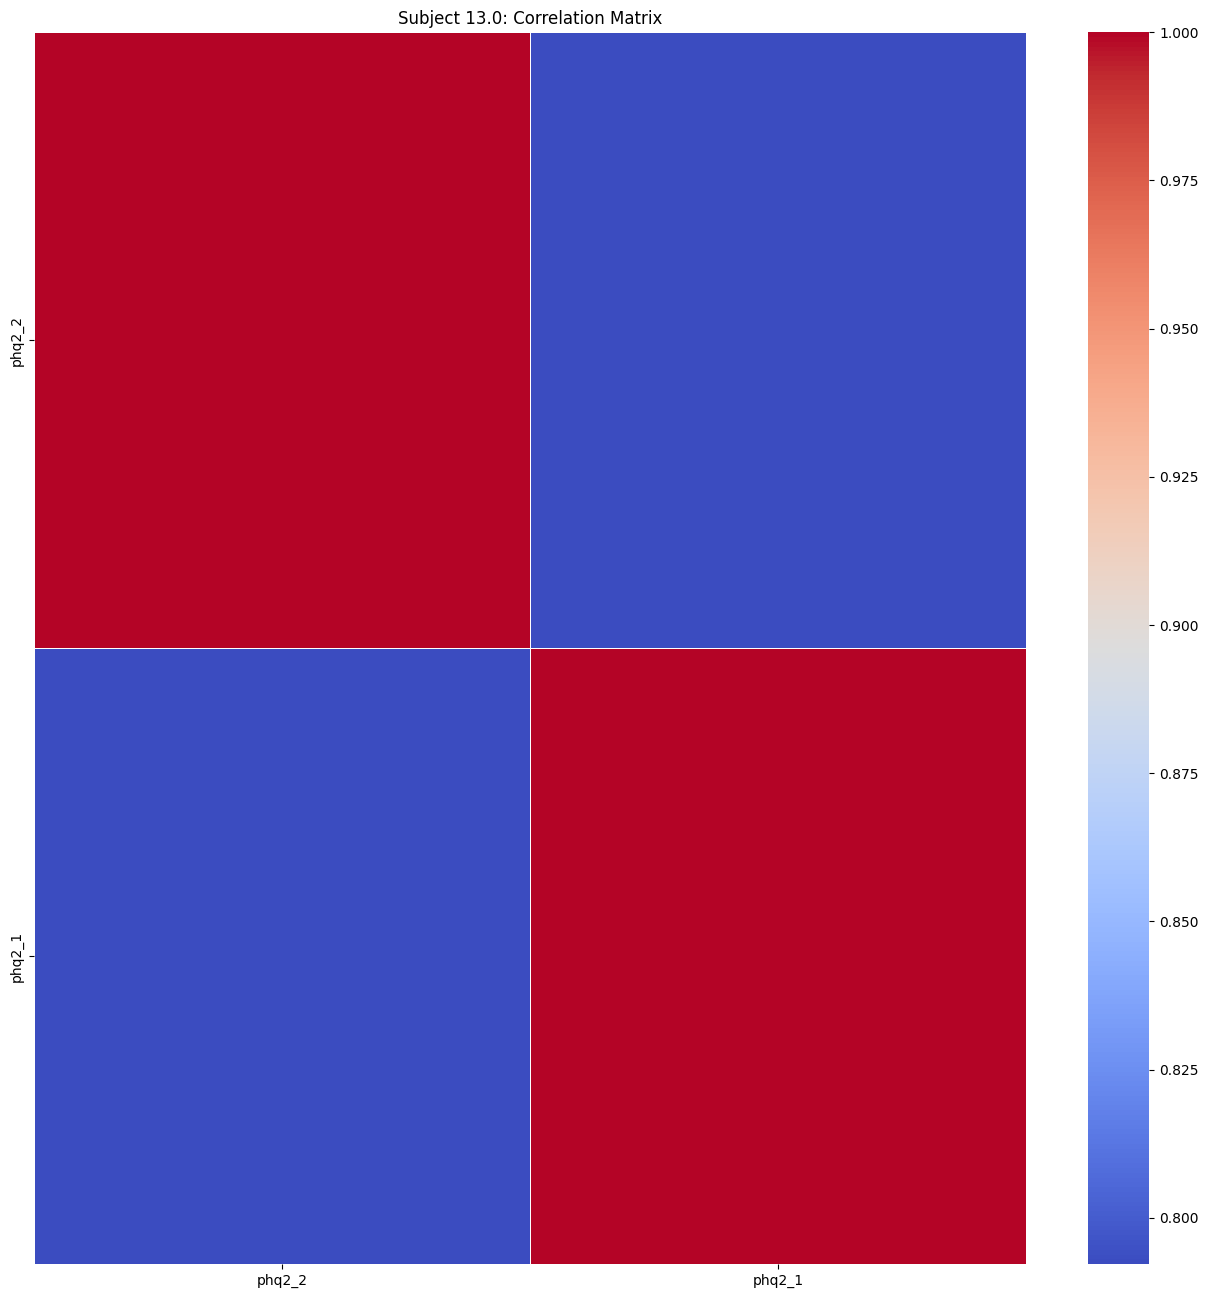

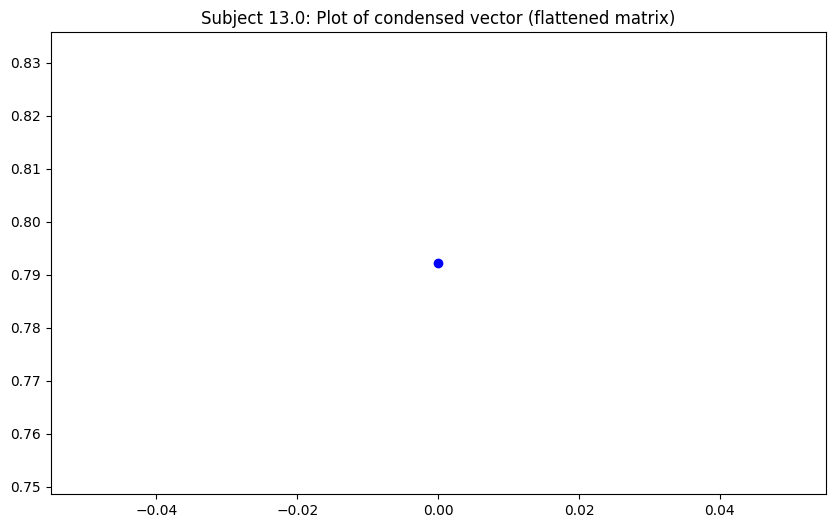

183 subs with symptom matrices
183 filled condensed arrays


DATAFRAME: v2_day
In df there are 161 subjects.
161 subs with symptom matrices
161 filled condensed arrays
In df there are 161 subjects.


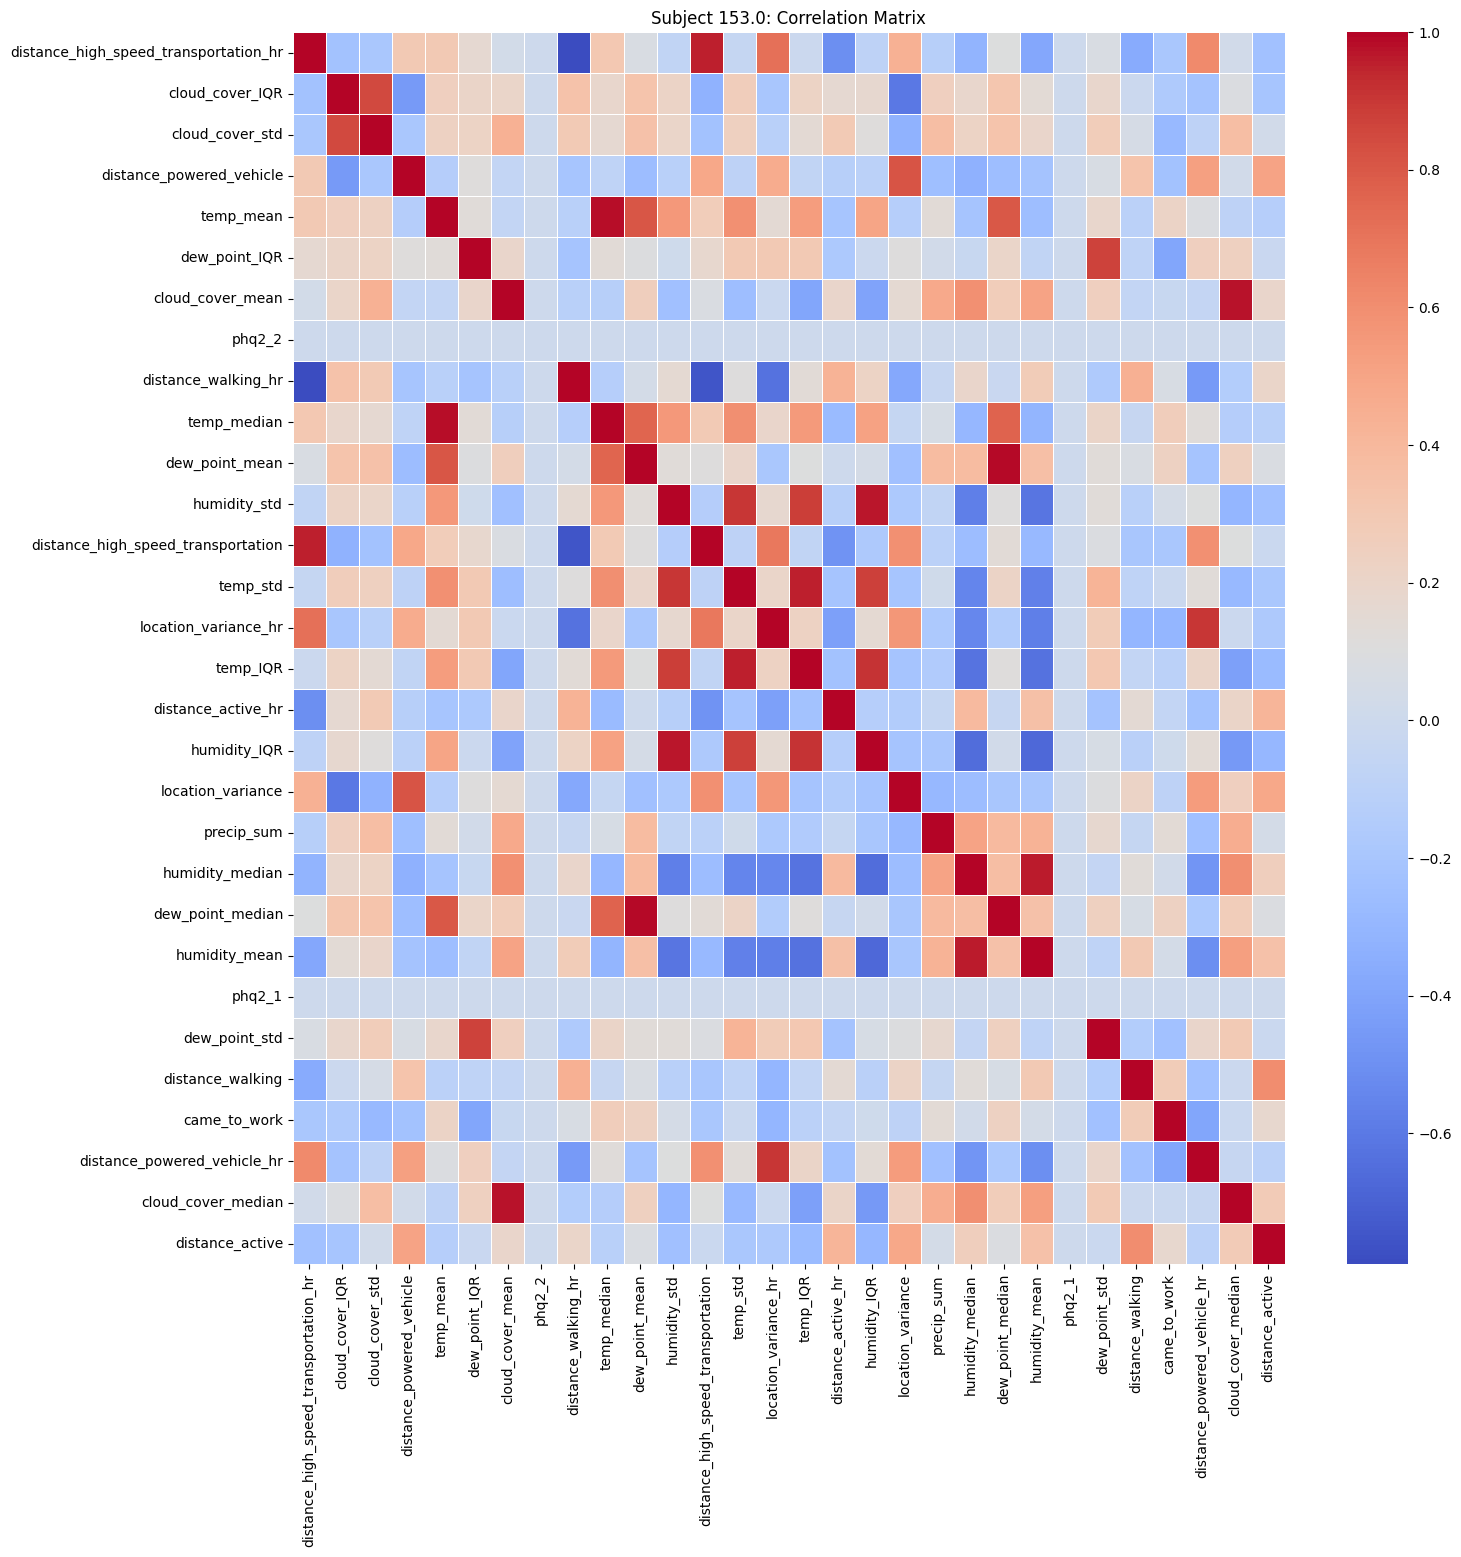

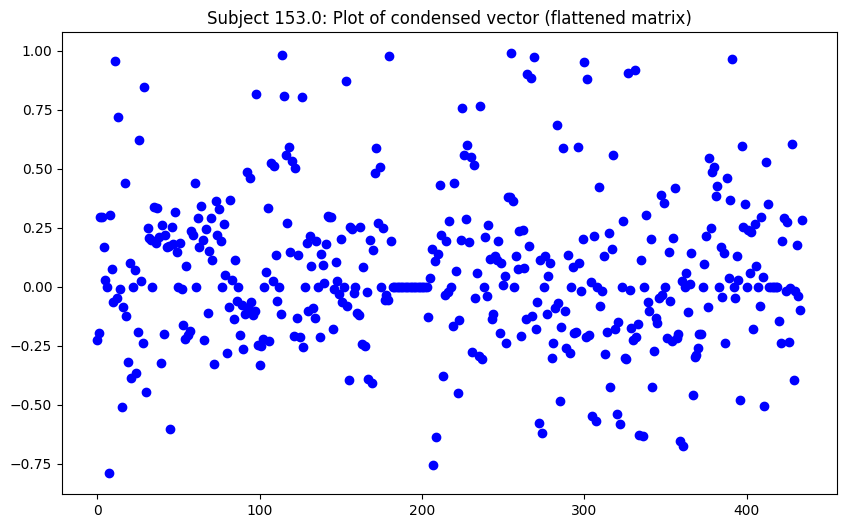

161 subs with symptom matrices
161 filled condensed arrays
In df there are 161 subjects.


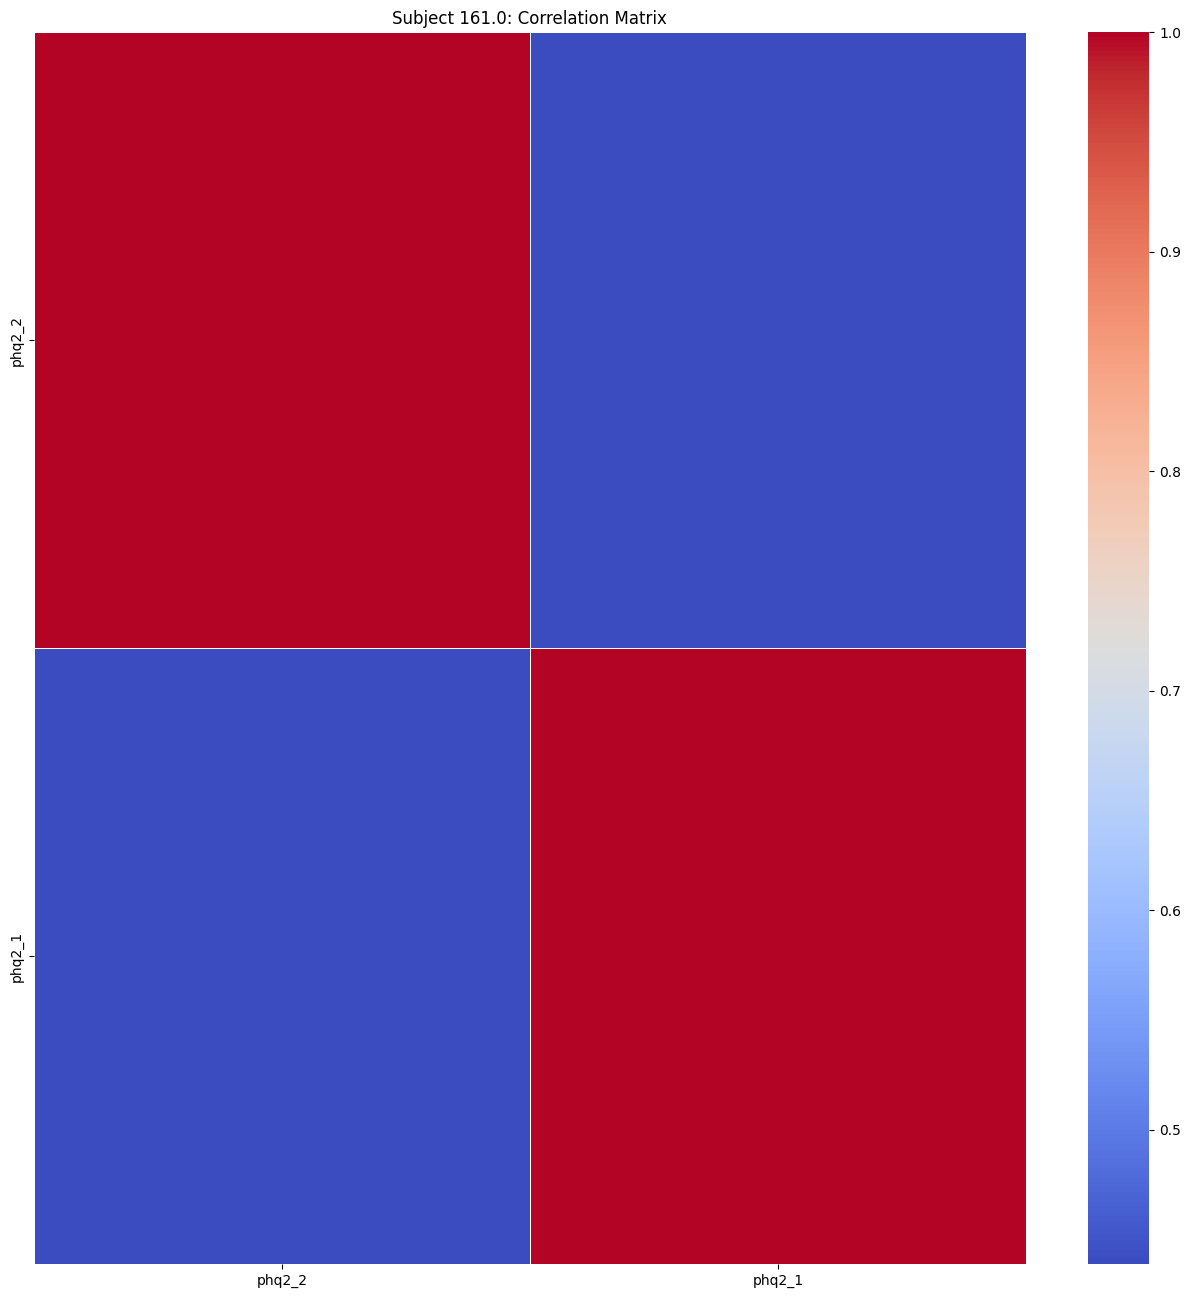

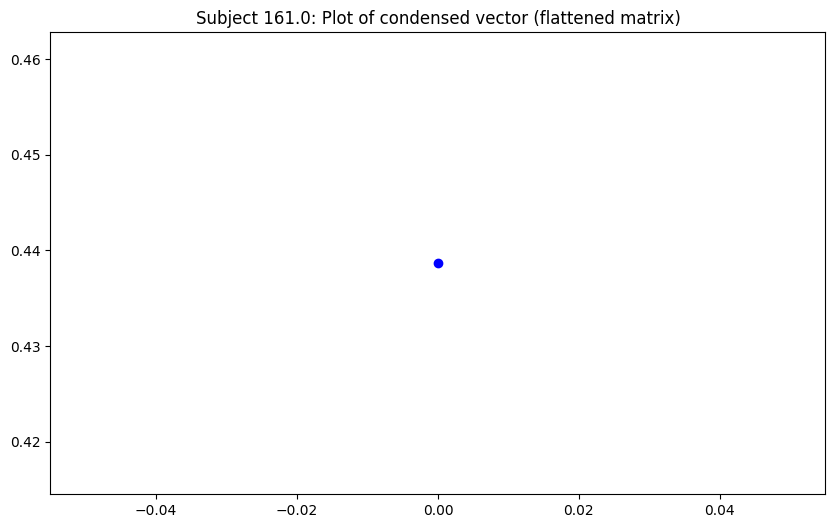

157 subs with symptom matrices
157 filled condensed arrays


DATAFRAME: v1_week
In df there are 180 subjects.
180 subs with symptom matrices
180 filled condensed arrays
In df there are 180 subjects.


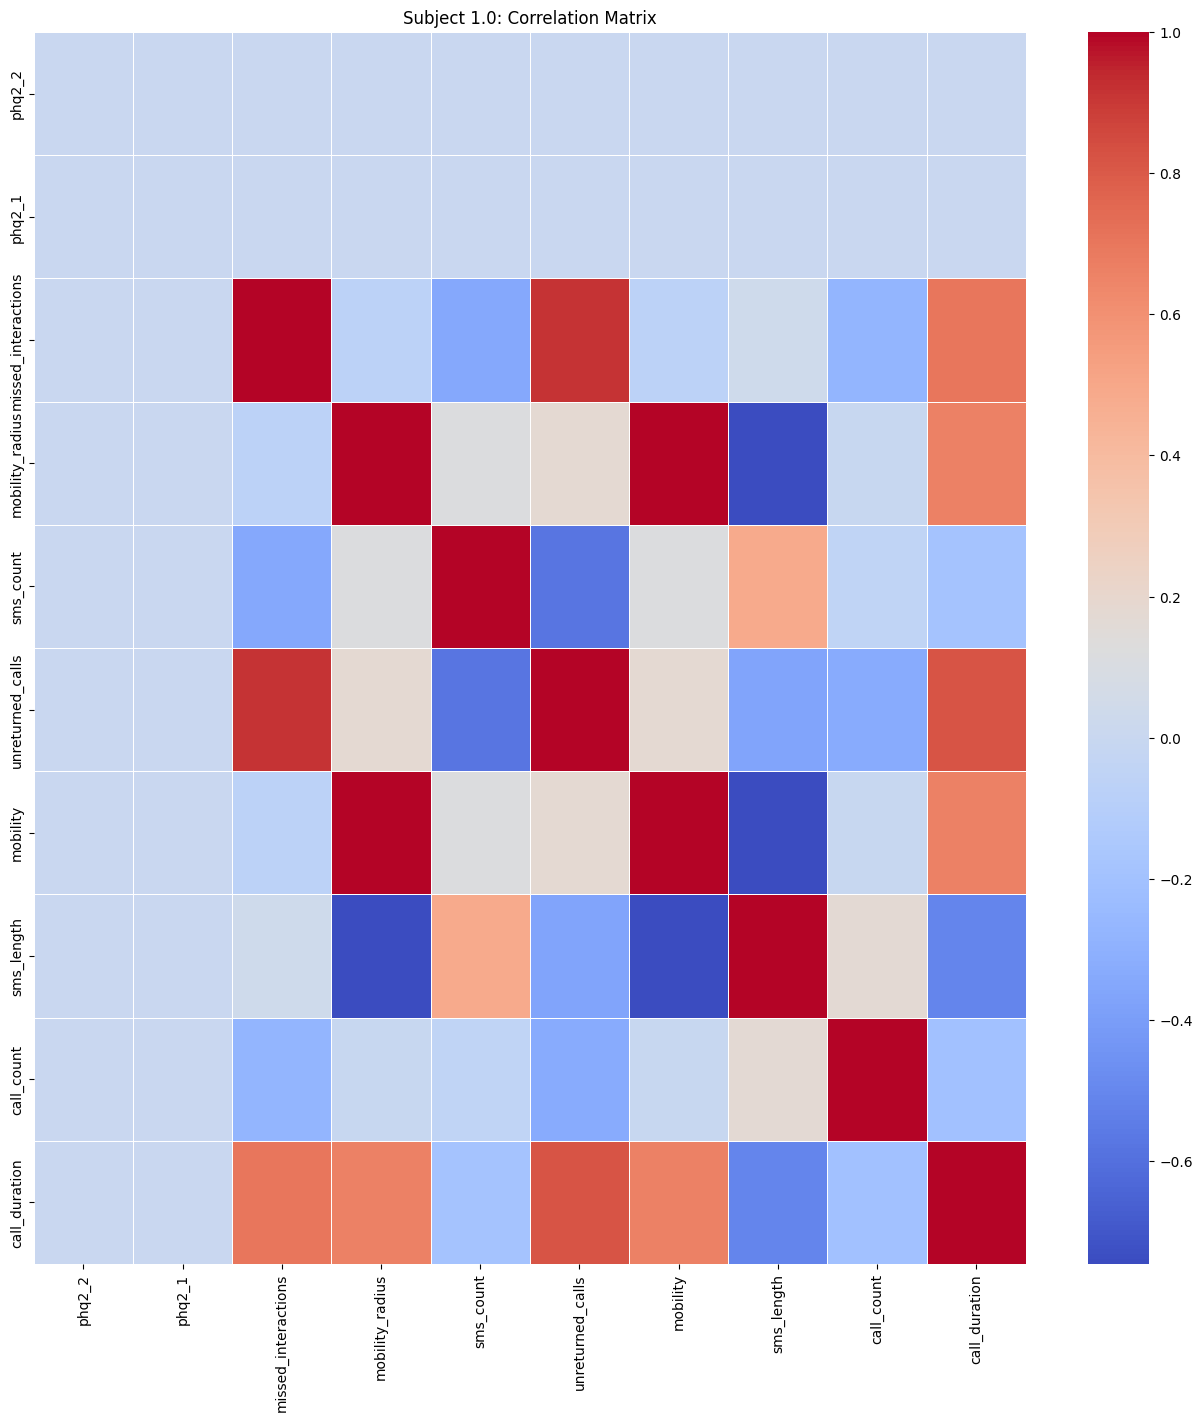

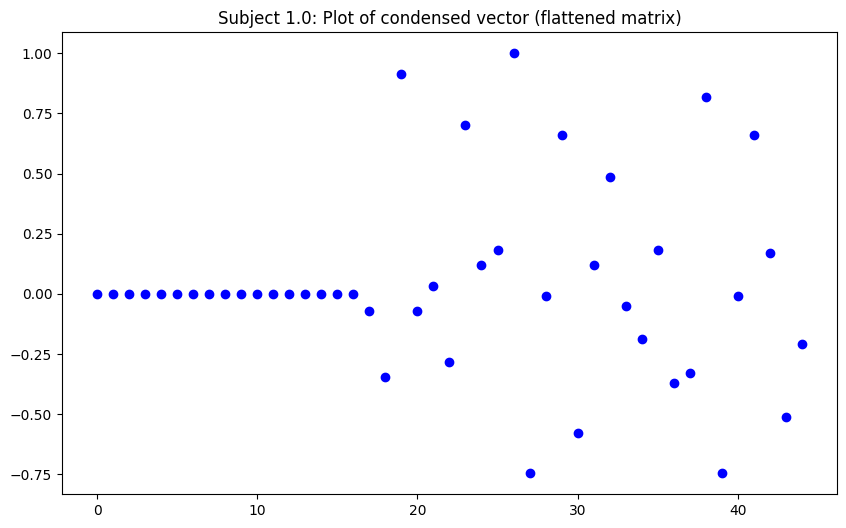

180 subs with symptom matrices
180 filled condensed arrays
In df there are 180 subjects.
0 subs with symptom matrices
0 filled condensed arrays


DATAFRAME: v2_week
In df there are 147 subjects.
147 subs with symptom matrices
147 filled condensed arrays
In df there are 147 subjects.


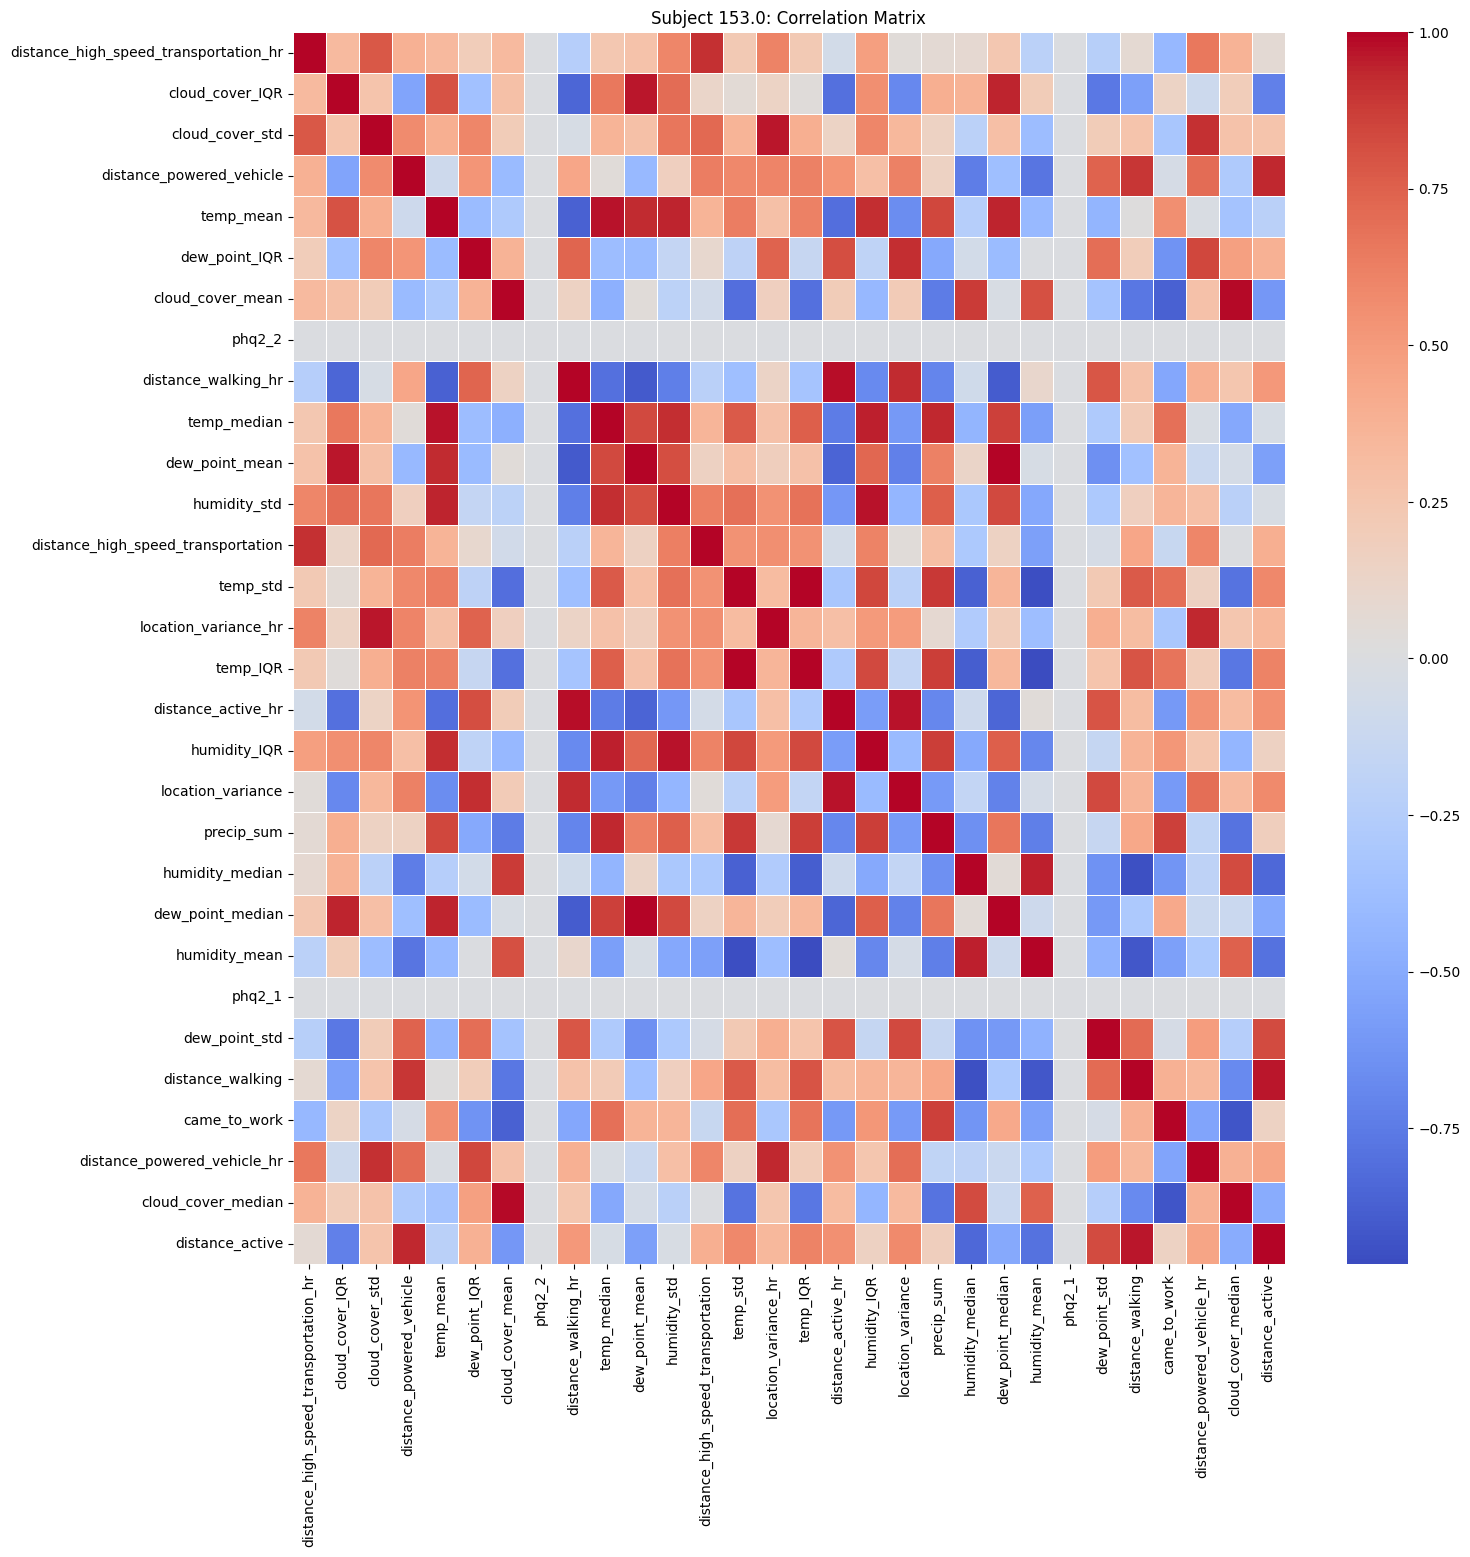

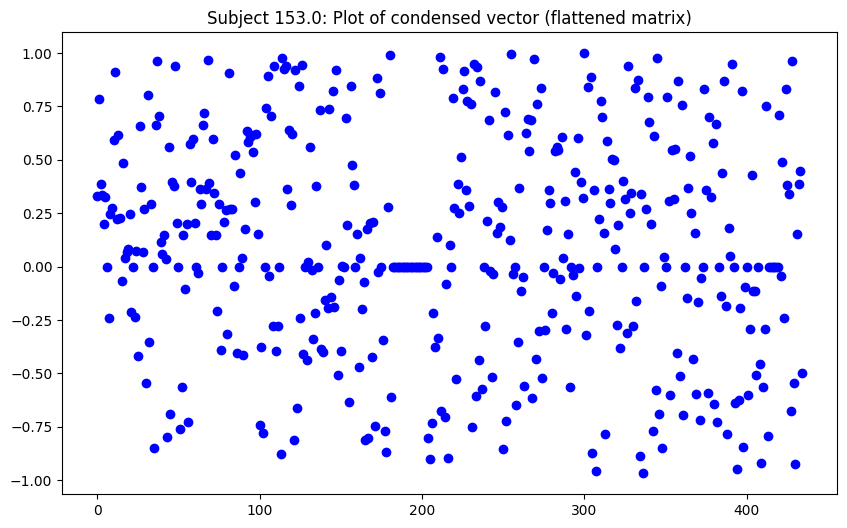

147 subs with symptom matrices
147 filled condensed arrays
In df there are 147 subjects.
0 subs with symptom matrices
0 filled condensed arrays


In [ ]:
#### Take the average of each subject's symptom correlation and use it to make clusters of variables
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

symptom_matrices_df_dict = {}
flattened_matrices_df_dict = {}
sensor_matrices_df_dict = {}
target_matrices_df_dict = {}
flattened_sensor_df_dict = {}
flattened_target_df_dict = {}

# Create dicts of all subjects' correlation matrices
for name in df_names:
	df = dfs[name].copy()
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

	print(f'\n\nDATAFRAME: {name}')
	column_order_all =  daily_cols_v1 + daily_cols_v2
	column_order = [col for col in column_order_all if col in df.columns]

	# Make symptom/flattened dicts for all cols
	symptom_matrix_dict, flattened_matrix_dict = fs.make_symptom_matrices(df, ignore_cols=non_pca_cols[name], num_to_plot=0, column_order=column_order)

	# Assign dicts to nested dict
	symptom_matrices_df_dict[name] = symptom_matrix_dict
	flattened_matrices_df_dict[name] = flattened_matrix_dict


	# Make separate symptom/flattened dicts for target cols vs. sensor cols
	if 'week' in name:
		target_cols = phq9_cols
		sensor_matrices_dict, flattened_sensor_dict = fs.make_symptom_matrices(df, ignore_cols=non_pca_cols[name], num_to_plot=1)
		non_target_df = df.copy().drop(columns=[col for col in df.columns if col not in target_cols and 'num_id' not in col])
		target_matrices_dict, flattened_target_dict = fs.make_symptom_matrices(non_target_df, ignore_cols=non_pca_cols[name], num_to_plot=1)

	if 'day' in name:
		target_cols = phq2_cols
		sensor_matrices_dict, flattened_sensor_dict = fs.make_symptom_matrices(df, ignore_cols=non_pca_cols[name]+weekly_cols, num_to_plot=1)
		non_target_df = df.copy().drop(columns=[col for col in df.columns if col not in target_cols and 'num_id' not in col])
		target_matrices_dict, flattened_target_dict = fs.make_symptom_matrices(non_target_df, ignore_cols=non_pca_cols[name], num_to_plot=1)

	# Assign sensor/target dicts to nested dict
	sensor_matrices_df_dict[name] = sensor_matrices_dict
	target_matrices_df_dict[name] = target_matrices_dict
	flattened_sensor_df_dict[name] = flattened_sensor_dict
	flattened_target_df_dict[name] = flattened_target_dict
	



Run on: Sun 12 Apr 2026, 10:50PM


/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


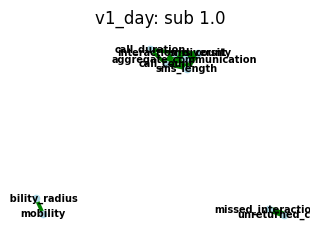

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


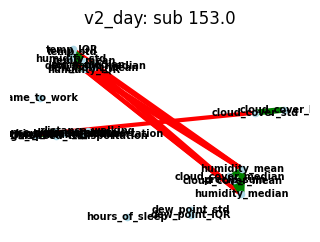

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


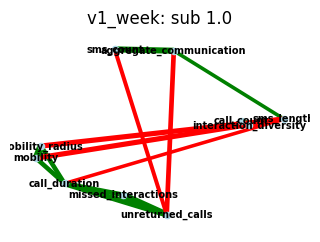

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


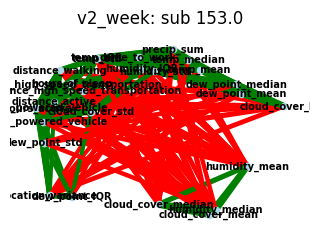

In [8]:
############### Plot individual networks of symptom matrices #################
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

for name, df_dict in symptom_matrices_df_dict.items():
	count=0
	for sub, corr_matrix in df_dict.items():
		if count<1:
			fs.plot_network(corr_matrix, title=f'{name}: sub {sub}')
			count=+1

In [9]:
# Double check where 'labels' are for columns
symptom_matrices_df_dict['v1_week'][list(symptom_matrices_df_dict['v1_week'].keys())[0]].index

Index(['aggregate_communication', 'call_count', 'call_duration',
       'interaction_diversity', 'missed_interactions', 'sms_count',
       'sms_length', 'mobility', 'mobility_radius', 'unreturned_calls'],
      dtype='object')

### Ok so temp mean and dew point IQR keep having relatively high correlations with the target variables, so we'll keep these, and drop the rest of the weather variables. Humidity also does but since it's highyl correlated with temp, we'll keep it out. 

# SENSORS PCA

Run on: Sun 12 Apr 2026, 10:50PM
v1_day
(10, 10) variables included


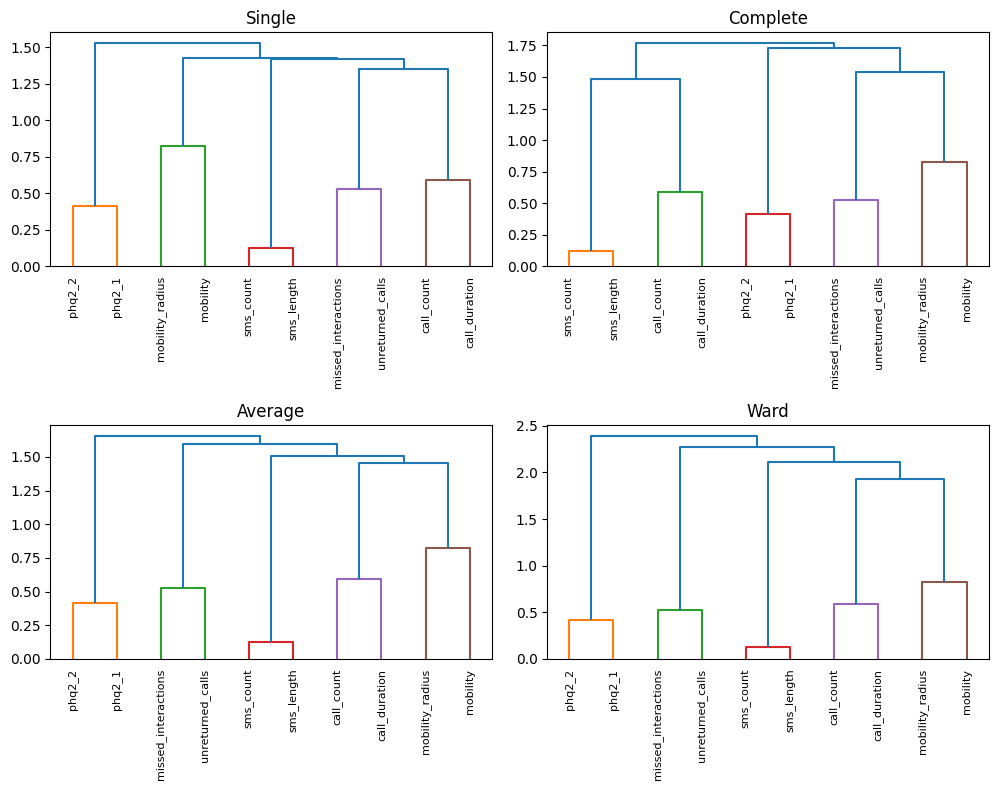

v2_day
(30, 30) variables included


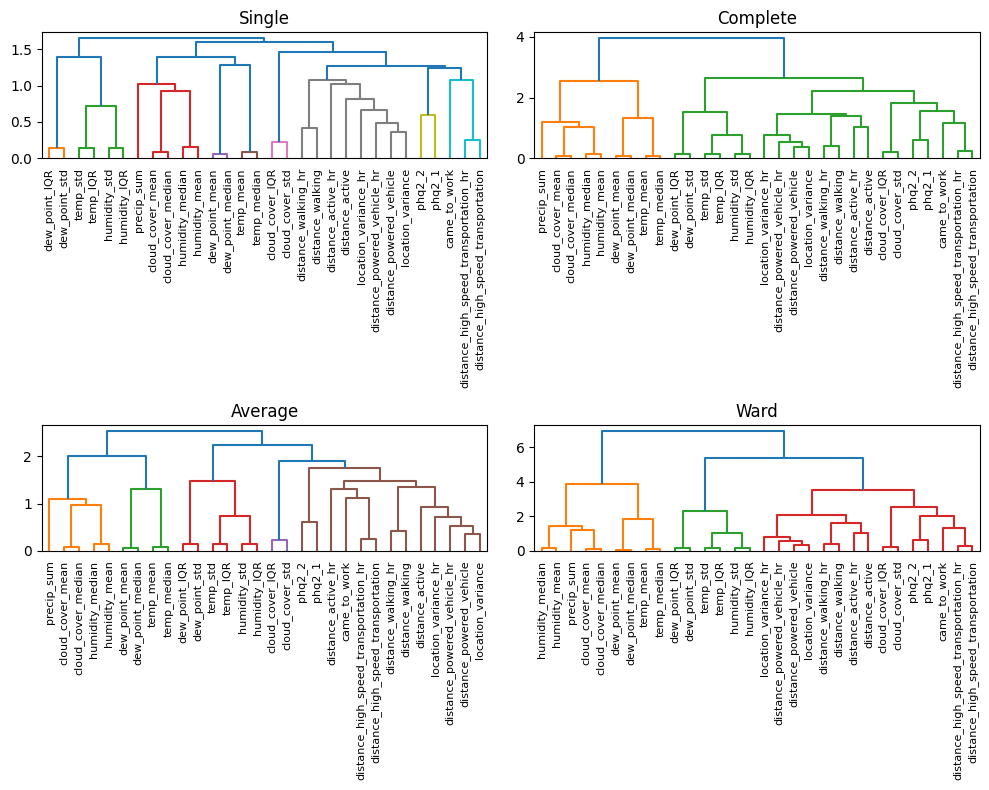

v1_week
(10, 10) variables included


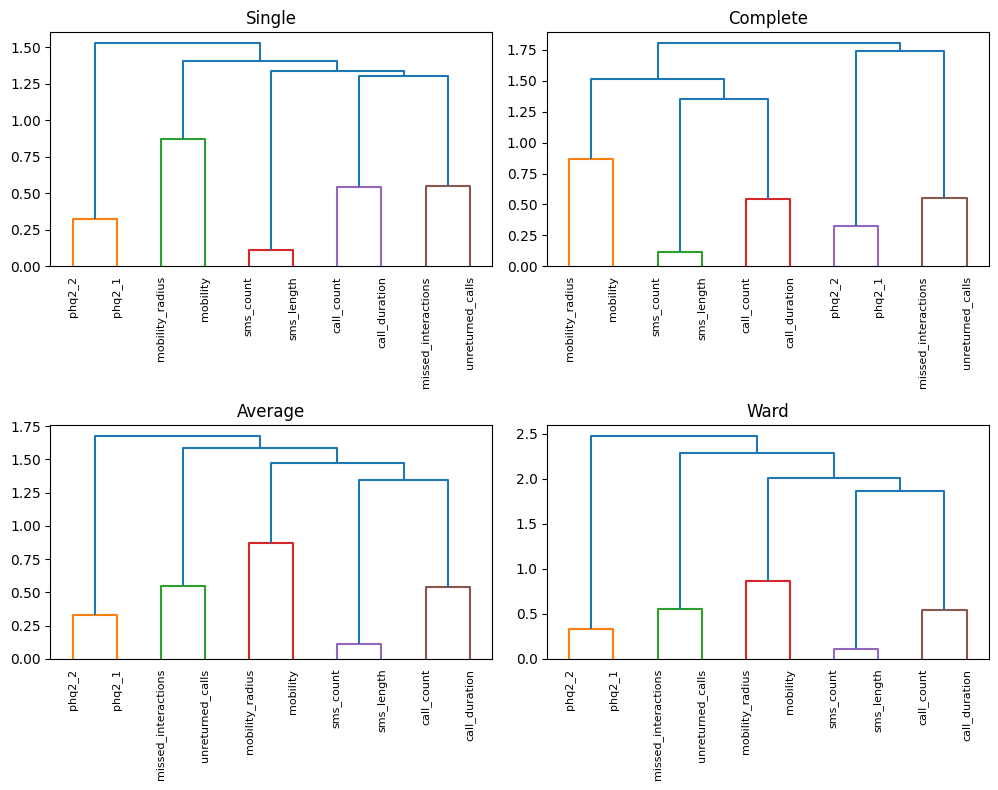

v2_week
(30, 30) variables included


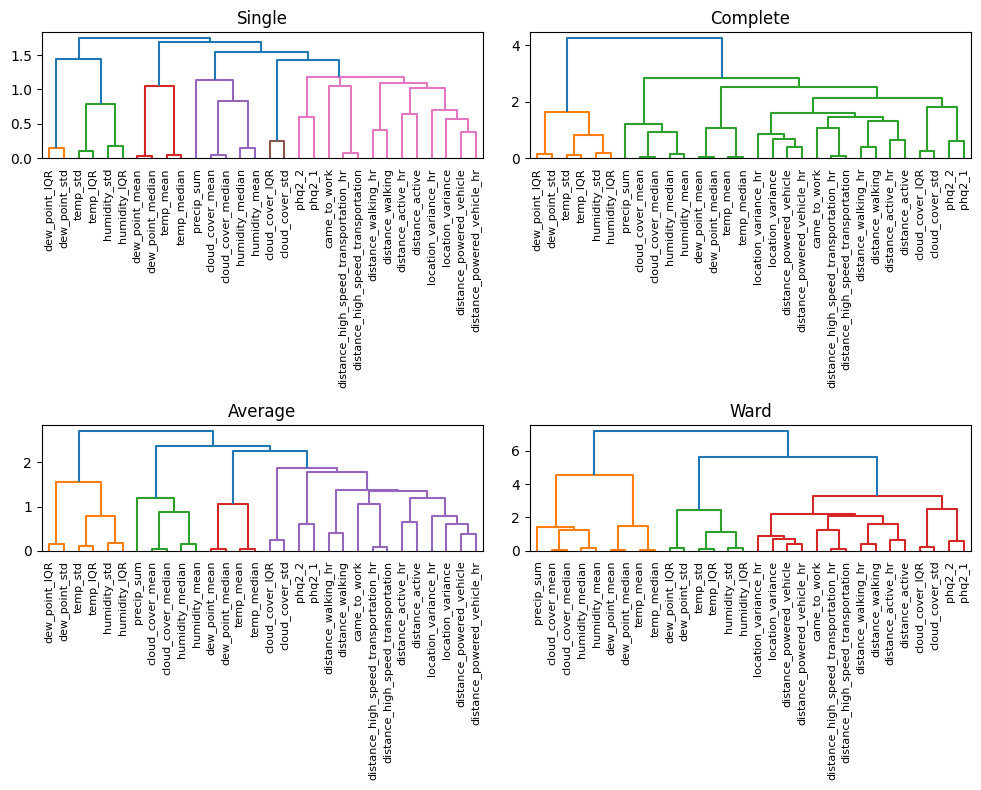

In [10]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

## Plot options
for name, df in sensor_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(df)
	fs.plot_hier_agg(avg_matrix, df[list(df.keys())[0]].index, is_dict=False, group_title=f'{name}') # 3, ward


### Mark down best fits:
* v1_day -> 5, single
* v2_day -> 8, single
* v1_week -> 6, average
* v2_week ->9, average

In [11]:
################# Create cluster_dict of Variables + Cluster Labels ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
importlib.reload(fs)

sensor_clust_dict = {}
# clust_dict['v1_day'] = v1_day_clust_dict
for name, dictionary in sensor_matrices_df_dict.items():
	avg_matrix = fs.average_matrix(dictionary)
	print(f'For {name}...')
	if 'v1_day' in name:
		sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=5, linkage='average', is_dict=False)
	if 'v2_day' in name:
	   sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=9, linkage='single', is_dict=False)
	if 'v1_week' in name:
		sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=6, linkage='average', is_dict=False)
	if 'v2_week' in name:
	   sensor_clust_dict[name] = fs.hier_agg_clustering(avg_matrix, dictionary[list(dictionary.keys())[0]].index, n_clusters=9, linkage='single', is_dict=False)

Run on: Sun 12 Apr 2026, 10:50PM
For v1_day...
For cluster 0, columns: ['mobility_radius', 'mobility']
For cluster 1, columns: ['call_count', 'call_duration']
For cluster 2, columns: ['missed_interactions', 'unreturned_calls']
For cluster 3, columns: ['sms_count', 'sms_length']
For cluster 4, columns: ['phq2_2', 'phq2_1']
For v2_day...
For cluster 0, columns: ['distance_high_speed_transportation_hr', 'distance_high_speed_transportation', 'came_to_work']
For cluster 1, columns: ['distance_powered_vehicle', 'distance_walking_hr', 'location_variance_hr', 'distance_active_hr', 'location_variance', 'distance_walking', 'distance_powered_vehicle_hr', 'distance_active']
For cluster 2, columns: ['cloud_cover_IQR', 'cloud_cover_std']
For cluster 3, columns: ['cloud_cover_mean', 'precip_sum', 'humidity_median', 'humidity_mean', 'cloud_cover_median']
For cluster 4, columns: ['temp_mean', 'temp_median']
For cluster 5, columns: ['dew_point_IQR', 'dew_point_std']
For cluster 6, columns: ['dew_point_m

In [ ]:
v1_day_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v1_day_trainval_imputed.csv'))
v1_week_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v1_week_trainval_imputed.csv'))
v2_day_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v2_day_trainval_imputed.csv'))
v2_week_trainval_imputed =pd.read_csv(os.path.join(brighten_dir, 'v2_week_trainval_imputed.csv'))


In [ ]:
################# Create df of Variables + 1st PC of clusters Labels ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))
importlib.reload(fs)
dfs_pca = {}
dfs_pca_dict = {}
test_pca = {}
test_pca_dict = {}
for name in df_names:
	print(f'\nFor {name}')

	df = dfs[name].copy()
	df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
	dfs_pca[name], dfs_pca_dict[name] = fs.pca_on_clusters(df, sensor_clust_dict[name], n_clusters=13) #n_clusters = number shown, so choose max
	
    # Make test df pca with the same clusters as defined by trainval, so we can use for prediction
	test_df=pd.read_csv(os.path.join(brighten_dir, f'{name}_test_imputed.csv'))
	test_df = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]
	test_pca[name], test_pca_dict[name] = fs.pca_on_clusters(test_df, sensor_clust_dict[name], n_clusters=13) #n_clusters = number shown, so choose max


Run on: Sun 12 Apr 2026, 10:50PM

For v1_day
Cols for cluster 0: ['mobility', 'mobility_radius']
Cols for cluster 1: ['call_duration', 'call_count']
Cols for cluster 2: ['unreturned_calls', 'missed_interactions']
Cols for cluster 3: ['sms_count', 'sms_length']
Cols for cluster 4: ['phq2_1', 'phq2_2']
Skipping cluster 5: No variables assigned.
Skipping cluster 6: No variables assigned.
Skipping cluster 7: No variables assigned.
Skipping cluster 8: No variables assigned.
Skipping cluster 9: No variables assigned.
Skipping cluster 10: No variables assigned.
Skipping cluster 11: No variables assigned.
Skipping cluster 12: No variables assigned.
Cols for cluster 0: ['mobility', 'mobility_radius']
Cols for cluster 1: ['call_duration', 'call_count']
Cols for cluster 2: ['unreturned_calls', 'missed_interactions']
Cols for cluster 3: ['sms_count', 'sms_length']
Cols for cluster 4: ['phq2_1', 'phq2_2']
Skipping cluster 5: No variables assigned.
Skipping cluster 6: No variables assigned.
Skipping

In [ ]:
# Create PCA loadings for Trainval DFs
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# v1_day
dfs_pca_dict['v1_day'][0]['name'] = 'pc_mobility'
dfs_pca_dict['v1_day'][1]['name'] = 'pc_calls'
dfs_pca_dict['v1_day'][2]['name'] = 'pc_unreturned_calls'
dfs_pca_dict['v1_day'][3]['name'] = 'pc_sms'
dfs_pca_dict['v1_day'][4]['name'] = 'pc_phq2'

# v2_day
dfs_pca_dict['v2_day'][0]['name'] = 'pc_commute' # transit/high speed
dfs_pca_dict['v2_day'][1]['name'] = 'pc_active_mobility'
dfs_pca_dict['v2_day'][2]['name'] = 'pc_cloud_cover_std'
dfs_pca_dict['v2_day'][3]['name'] = 'pc_weather_means' # humidity, cloud cover, precip
dfs_pca_dict['v2_day'][4]['name'] = 'pc_temp_humidity_std'
dfs_pca_dict['v2_day'][5]['name'] = 'pc_dew_point'
dfs_pca_dict['v2_day'][6]['name'] = 'pc_dew_point_std'
dfs_pca_dict['v2_day'][7]['name'] = 'pc_temp'
dfs_pca_dict['v2_day'][8]['name'] = 'pc_phq2'

# v1_week
dfs_pca_dict['v1_week'][0]['name'] = 'pc_unreturned_calls'
dfs_pca_dict['v1_week'][1]['name'] = 'pc_calls'
dfs_pca_dict['v1_week'][2]['name'] = 'pc_mobility'
dfs_pca_dict['v1_week'][3]['name'] = 'pc_phq2'
dfs_pca_dict['v1_week'][4]['name'] = 'pc_sms'
dfs_pca_dict['v1_week'][5]['name'] = 'pc_mobility_radius'

# v2_week
dfs_pca_dict['v2_week'][0]['name'] = 'pc_active_mobility'
dfs_pca_dict['v2_week'][1]['name'] = 'pc_commute'
dfs_pca_dict['v2_week'][2]['name'] = 'pc_temp_dew_point'
dfs_pca_dict['v2_week'][3]['name'] = 'pc_humidity_cloud_mean'
dfs_pca_dict['v2_week'][4]['name'] = 'pc_cloud_cover_std'
dfs_pca_dict['v2_week'][5]['name'] = 'pc_dew_point_std'
dfs_pca_dict['v2_week'][6]['name'] = 'pc_phq2'
dfs_pca_dict['v2_week'][7]['name'] = 'pc_temp_humidity_std'
dfs_pca_dict['v2_week'][8]['name'] = 'pc_precip'


for name in df_names:
	df = dfs[name].copy()
	dfs_pca[name] = fs.merge_df_via_cluster_pca_dict(df, dfs_pca_dict[name], on_columns=['num_id', 'day'])
	dfs_pca[name].to_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'), index=False)



Run on: Sun 12 Apr 2026, 10:50PM


In [16]:
# Create PCA loadings for Test DFs
# But its' not getting visualized anywhere
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

# v1_day
test_pca_dict['v1_day'][0]['name'] = 'pc_mobility'
test_pca_dict['v1_day'][1]['name'] = 'pc_calls'
test_pca_dict['v1_day'][2]['name'] = 'pc_unreturned_calls'
test_pca_dict['v1_day'][3]['name'] = 'pc_sms'
test_pca_dict['v1_day'][4]['name'] = 'pc_phq2'

# v2_day
test_pca_dict['v2_day'][0]['name'] = 'pc_commute' # transit/high speed
test_pca_dict['v2_day'][1]['name'] = 'pc_active_mobility'
test_pca_dict['v2_day'][2]['name'] = 'pc_cloud_cover_std'
test_pca_dict['v2_day'][3]['name'] = 'pc_weather_means' # humidity, cloud cover, precip
test_pca_dict['v2_day'][4]['name'] = 'pc_temp_humidity_std'
test_pca_dict['v2_day'][5]['name'] = 'pc_dew_point'
test_pca_dict['v2_day'][6]['name'] = 'pc_dew_point_std'
test_pca_dict['v2_day'][7]['name'] = 'pc_temp'
test_pca_dict['v2_day'][8]['name'] = 'pc_phq2'

# v1_week
test_pca_dict['v1_week'][0]['name'] = 'pc_unreturned_calls'
test_pca_dict['v1_week'][1]['name'] = 'pc_calls'
test_pca_dict['v1_week'][2]['name'] = 'pc_mobility'
test_pca_dict['v1_week'][3]['name'] = 'pc_phq2'
test_pca_dict['v1_week'][4]['name'] = 'pc_sms'
test_pca_dict['v1_week'][5]['name'] = 'pc_mobility_radius'

# v2_week
test_pca_dict['v2_week'][0]['name'] = 'pc_active_mobility'
test_pca_dict['v2_week'][1]['name'] = 'pc_commute'
test_pca_dict['v2_week'][2]['name'] = 'pc_temp_dew_point'
test_pca_dict['v2_week'][3]['name'] = 'pc_humidity_cloud_mean'
test_pca_dict['v2_week'][4]['name'] = 'pc_cloud_cover_std'
test_pca_dict['v2_week'][5]['name'] = 'pc_dew_point_std'
test_pca_dict['v2_week'][6]['name'] = 'pc_phq2'
test_pca_dict['v2_week'][7]['name'] = 'pc_temp_humidity_std'
test_pca_dict['v2_week'][8]['name'] = 'pc_precip'


for name in df_names:
	test_df_scaled = pd.read_csv(os.path.join(brighten_dir, f'{name}_test_imputed.csv'))
	test_pca[name] = fs.merge_df_via_cluster_pca_dict(test_df_scaled, test_pca_dict[name], on_columns=['num_id', 'day'])
	test_pca[name].to_csv(os.path.join(brighten_dir, f'{name}_test_pca.csv'), index=False)




Run on: Sun 12 Apr 2026, 10:50PM


Run on: Sun 12 Apr 2026, 10:50PM


/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


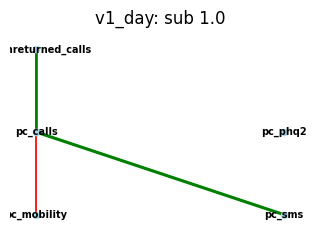

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


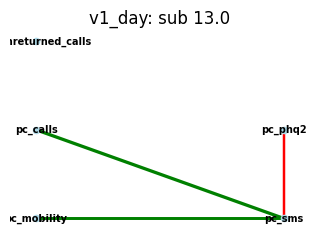

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


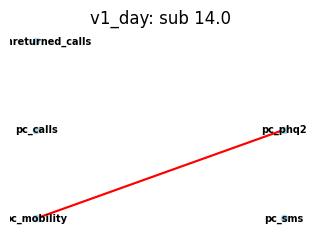

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


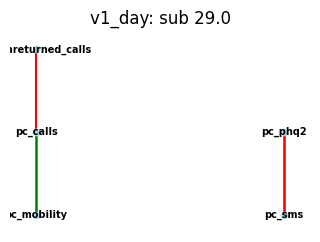

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


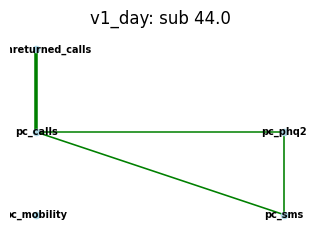

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


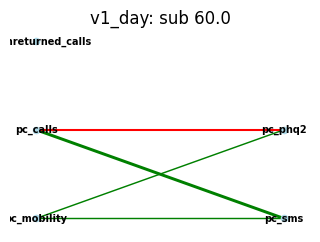

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


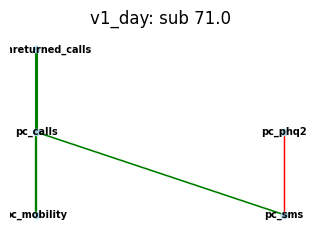

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


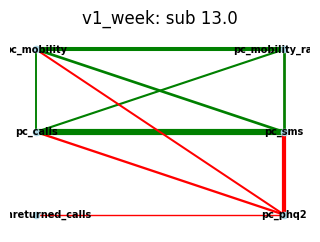

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


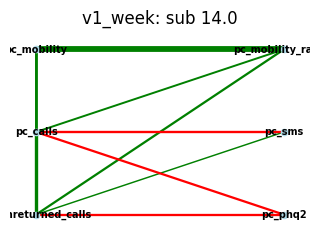

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


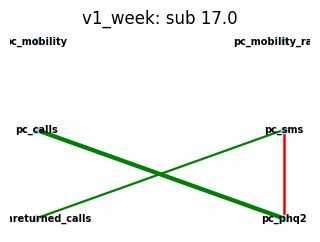

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


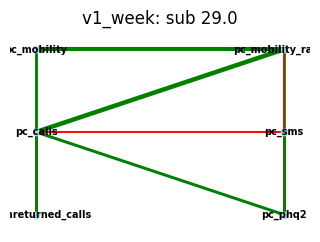

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


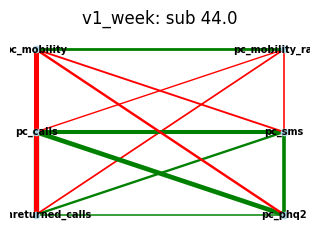

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


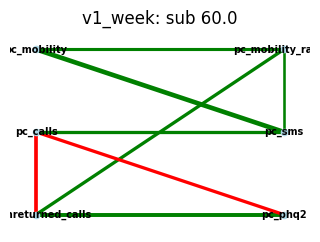

/Users/klj9278/Library/CloudStorage/Box-Box/brighten_analysis/scripts/feature_selection.py:378: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


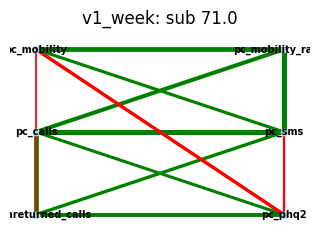

In [17]:
############ Plot subjects' individual networks of PCs ############
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))


fixed_positions_v1_day = {
    'pc_mobility': (1, 1),
    'pc_calls': (1, 2),
    'pc_unreturned_calls': (1, 3),
    'pc_sms': (2, 1),
    'pc_phq2': (2, 2)
}

fixed_positions_v2_day = {
    'pc_commute': (1, 1),
    'pc_active_mobility': (1, 2),
    'pc_cloud_cover_std': (1, 3),
    'pc_weather_means': (2, 1),
    'pc_temp_humidity_std': (2, 2),
    'pc_dew_point': (2, 3),
    'pc_dew_point_std': (3, 1),
    'pc_temp': (3, 2),
    'pc_phq2': (3, 3)
}

fixed_positions_v1_week = {
    'pc_unreturned_calls': (1, 1),
    'pc_calls': (1, 2),
    'pc_mobility': (1, 3),
    'pc_phq2': (2, 1),
    'pc_sms': (2, 2),
    'pc_mobility_radius': (2, 3)
}

fixed_positions_v2_week = {
    'pc_active_mobility': (1, 1),
    'pc_commute': (1, 2),
    'pc_temp_dew_point': (1, 3),
    'pc_humidity_cloud_mean': (2, 1),
    'pc_cloud_cover_std': (2, 2),
    'pc_dew_point_std': (2, 3),
    'pc_phq2': (3, 1),
    'pc_temp_humidity_std': (3, 2),
    'pc_precip': (3, 3)
}

for name, df in dfs_pca.items():
	count, count2 = 0, 0
	
	cols=[col for col in df.columns.to_list() if 'pc_' in col]
	for sub in df['num_id'].unique():
		sub_df = df[df['num_id']==sub]
		corr_matrix=sub_df[cols].corr()
		if sub_df.shape[0] > 8:
			if count<7:
				if 'v1_day' in name:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_day)
					count+=1
			if count2<7:
				if 'v1_week' in name:
					fs.plot_network(corr_matrix, title=f'{name}: sub {sub}', threshold=0.2, fixed_positions=fixed_positions_v1_week)
					count2+=1


## Checking for collinearity


Run on: Sun 12 Apr 2026, 10:50PM


For v1_day:


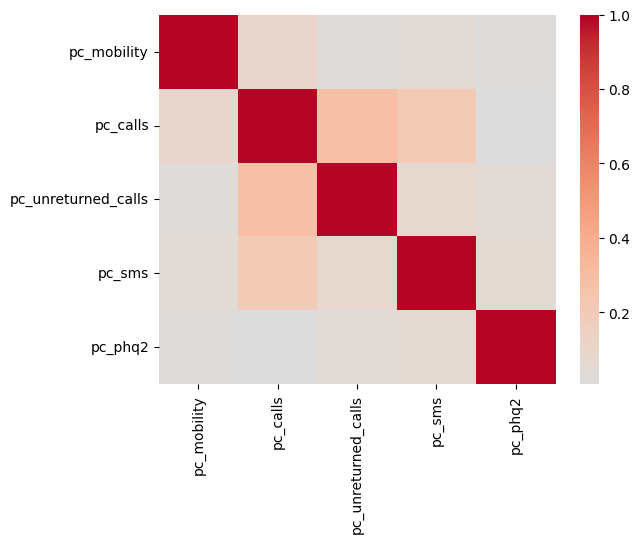



For v2_day:


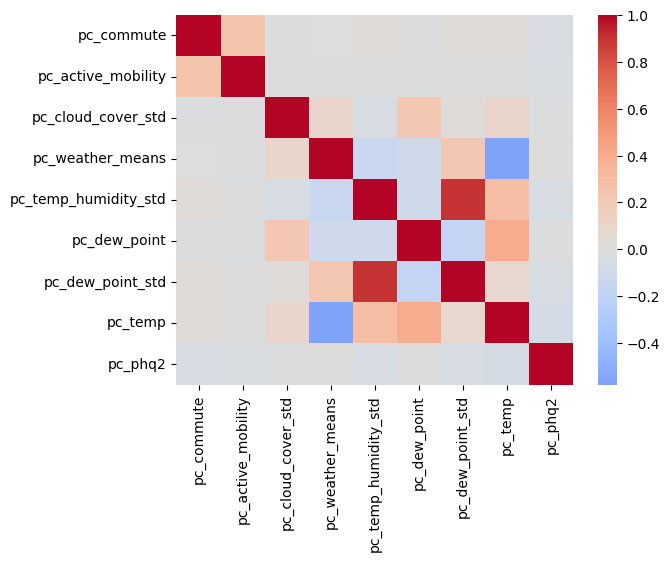



For v1_week:


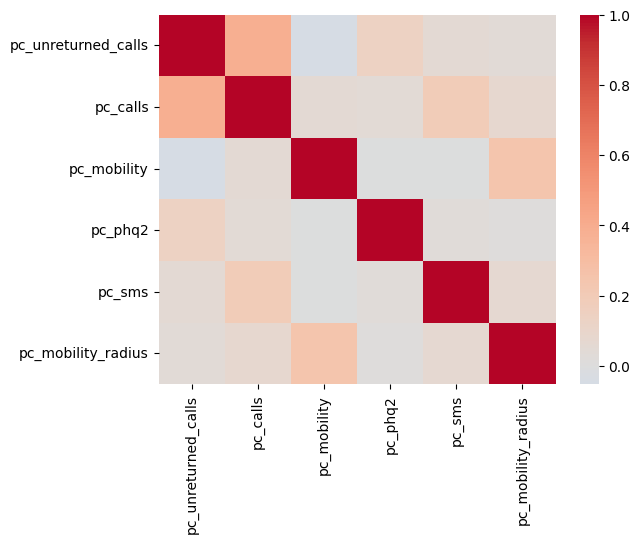



For v2_week:


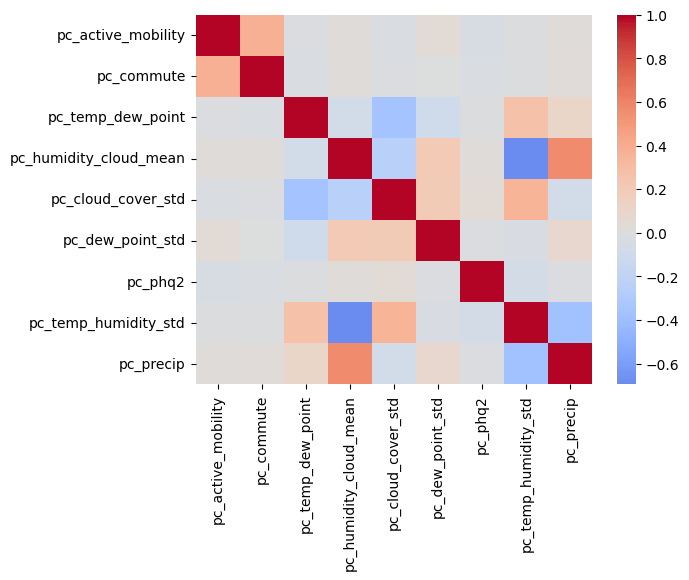

In [18]:
print('Run on:', dt.datetime.today().strftime('%a %d %b %Y, %I:%M%p'))

for name in df_names:
	df = pd.read_csv(os.path.join(brighten_dir, f'{name}_trainval_pca.csv'))
	print(f'\n\nFor {name}:')
	numeric_cols = [col for col in df.columns.to_list() if 'pc_' in col]
	sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0)
	plt.show()

We can see that our features are successfull not correlated, except phq2 and phq9, which is expected, and in most cases, phq2 won't be used to predict phq9. 

In [19]:
# ### Create lag variable
# for name in df_names:
#     df = pd.read_csv(os.path.join(brighten_dir, f'{name}_pca.csv'))
#     print(f'\n\nFor {name}:')
#     lag = phq9_cols + phq2_cols
#     to_lag = [col for col in lag if col in df.columns]
#     df_lag = pre.create_lag_variables(df, to_lag)
#     df_lag.to_csv(os.path.join(brighten_dir, f'{name}_pca_lag.csv'), index=False)
#     print(f"Saved {name}_pca_lag.csv to brighten_dir")

